# State Space Models with `dynestyx` and `numpyro_forecast`

In this notebook we write a [`dynestyx`](https://github.com/BasisResearch/dynestyx) state space model as a `numpyro_forecast` model. We then fit it, forecast with it and backtest it with the drivers of the package, unchanged.

`dynestyx` is a probabilistic programming library for dynamical systems built on NumPyro. Its central object is a `DynamicalModel`, which bundles an initial condition, a state evolution and an observation model. Its single primitive, `dsx.sample`, is interpreted by effect handlers: a `Filter` or a `Smoother` marginalizes the latent path with a filtering algorithm (Kalman, ensemble Kalman, extended and unscented Kalman, particle filters) and adds the marginal log likelihood to the NumPyro trace, a `LatentPathBuilder` samples the path explicitly, and a `Simulator` rolls the model forward in time.

`numpyro_forecast` is a forecasting workflow layer. A model is a plain function `(covariates, data=None)` built from model building blocks that register the `"obs"` and `"forecast"` sites, and the drivers ([`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html), [`predict_in_sample`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.predict_in_sample.html), [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html), [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) and the metrics) read those sites by name.

The two libraries compose at the trace level. We connect them with one new model building block, `state_space_series`. Its `conditioner` argument is the `dynestyx` handler that interprets `dsx.sample` over the observed window, so the choice between marginalizing the latent path (a `Smoother`) and sampling it explicitly (a `LatentPathBuilder`) is a one-argument change.

We proceed as follows:

1. **Prepare Notebook.** We load the libraries and set the configuration.
2. **The Building Block.** We define `state_space_series` and explain its contract.
3. **Local Level Model.** We fit the same generative process three times: in the direct form of the package, with `dynestyx` sampling the path explicitly, and with `dynestyx` marginalizing it with a Kalman smoother. We compare posteriors, sampler efficiency, forecasts, in-sample fits and the reconstructed latent level.
4. **Seasonal Regression Model.** We add a seasonal regression through the covariates, fit it with SVI and run the expanding-window backtest of the package on the `dynestyx` model, in and out of sample. This is the evaluation direction suggested in [dynestyx#264](https://github.com/BasisResearch/dynestyx/issues/264).
5. **Conclusion.** We summarize the findings, the limitations and our recommendations.

## Prepare Notebook

We load the necessary libraries and set the notebook's configuration.

In [1]:
import time
from collections.abc import Sequence
from contextlib import ExitStack
from dataclasses import dataclass
from functools import partial
from typing import Any

import arviz as az
import dynestyx as dsx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from dynestyx import Discretizer, DynamicalModel, Filter, LatentPathBuilder, Simulator, Smoother
from dynestyx.inference.configs.simulator import SimulatorConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig
from dynestyx.inference.filters import KFConfig
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    results_to_dataframe,
    to_datatree,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

print(f"dynestyx {dsx.__version__}, numpyro {numpyro.__version__}, jax {jax.__version__}")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

dynestyx 0.5.1, numpyro 0.21.0, jax 0.11.0


## The Building Block

The block below is the whole integration, and its docstring states the contract. It takes the current call's [`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html), a site name, the observed window `y`, a `dynestyx` `DynamicalModel` and a **conditioner**. The conditioner is the stack of `dynestyx` handlers that interpret `dsx.sample` over the observed window, and it takes one of three forms:

- **`Filter` or `Smoother`**: they compute the marginal log likelihood $\log p(y_{1:T} \mid \theta)$ of the window and register it as a NumPyro factor, so the joint density that NUTS or SVI sees is $p(\theta) \, p(y_{1:T} \mid \theta)$ with the latent path integrated out. The smoother additionally carries the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ of every in-window state, which the filter does not, and it costs nothing extra during fitting.
- **`LatentPathBuilder`**: it creates one sample site for the whole path and registers the joint state-observation density as a factor. The sampler explores the path explicitly, as it does with the package's own [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html), but `dynestyx` builds the path, which is the road to discretized continuous-time dynamics and to observation models that handle missing values.
- **`Discretizer`**: it may follow either of the above, as the second element of a sequence, to turn a continuous-time model into the discrete transition the conditioning handler consumes. We stay with discrete-time models here, and the design document records the continuous-time recipe and its caveats.

How does the block tell the modes apart? It reads the observed window from its `y` argument, sliced from `covariates` by the model (the series doubles as a covariate, exactly the contract of [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)), and it uses `h.data` only as a mode switch. Training runs `dsx.sample` under the stack.

Forecasting nests the stack inside a `Simulator`, which `dynestyx` interprets as a posterior rollout from the conditioned state at the last observed step, and registers the horizon draws as the `"forecast"` site.

When a driver calls the model without data, the observed window still arrives through `covariates`. The block then draws the in-window states from the conditioner's posterior over the path (the smoothing distribution, or the explicit path), samples one observation per step from the observation model and registers them as the `"obs"` site. In other words, `data=None` is a mode switch and not an absence of data: the in-sample predictive is a smoothing task, which is why a `Filter` conditioner raises in this mode.

Because the block owns the likelihood, it owns the two sites too, like [`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html). A model is its horizon, its parameters and one call. The block returns a `StateSpaceResult` with the state draws of the current mode, `x_future` over the horizon and `x_in_sample` over the window, for a model that wants to register its latent level.

Here are two important remarks about the time grids and the rollout. First, the `Horizon` counts the steps and the `times` argument places them: the block slices the observation times from `times` and takes the last `future` entries as the forecast times (any strictly increasing grid, regular or not, and the step index by default). It hands them to `dynestyx` as NumPy constants for a `Filter` or `Smoother`, whose rollout does its segment bookkeeping on the host, and as jax arrays for a `LatentPathBuilder`, which indexes them inside a scan. The drivers run the model under `jax.jit`, so a grid derived from a traced covariate column would break the first case.

Second, the prediction grid starts at the last observed step, `t_obs - 1`, and the block drops the first returned row. The simulator's first predicted state is the conditioned draw at `predict_times[0]` without a transition, so anchoring there yields exactly one transition per horizon step. Starting at `t_obs` instead would silently report the state of step `t_obs - 1` as the forecast for `t_obs`.

Keep this in mind: create the handlers once, outside the model. They are `dynestyx` objects with state of their own, and the builder caches the observation layout it needs to run under `jit`.

In [2]:
StateSpaceHandler = Filter | Smoother | LatentPathBuilder | Discretizer
"""A dynestyx handler that interprets ``dsx.sample`` over the observed window."""

_CONDITIONING_HANDLERS = (Filter, Smoother, LatentPathBuilder)


@dataclass(frozen=True)
class StateSpaceResult:
    """Draws produced by `state_space_series` (size-0 time axes when not applicable).

    Each field is filled in the mode that produces it and has a size-0 time axis
    otherwise: the ``future`` fields while forecasting, the ``in_sample`` fields
    when the model is called without data, none while training. The shapes carry
    no batch dims (panels are not supported).

    Attributes
    ----------
    y_future
        Observation draws over the horizon, shape ``(future, obs)``; also
        registered as the ``"forecast"`` site.
    x_future
        Latent state draws over the horizon, shape ``(future, state)``.
    y_in_sample
        One draw of the in-sample predictive, shape ``(t_obs, obs)``; also
        registered as the ``"obs"`` site.
    x_in_sample
        The in-window state draw behind ``y_in_sample``, shape ``(t_obs, state)``:
        the conditioner's posterior over the path (the smoothing distribution, or
        the explicit path), one draw per model call.
    """

    y_future: Float[Array, " future obs"]
    x_future: Float[Array, " future state"]
    y_in_sample: Float[Array, " time obs"]
    x_in_sample: Float[Array, " time state"]


def _handler_stack(
    conditioner: StateSpaceHandler | Sequence[StateSpaceHandler],
) -> tuple[StateSpaceHandler, ...]:
    """Normalize ``conditioner`` to the tuple of handlers entered outermost first."""
    stack = tuple(conditioner) if isinstance(conditioner, Sequence) else (conditioner,)
    conditioning = [i for i, h in enumerate(stack) if isinstance(h, _CONDITIONING_HANDLERS)]
    if len(conditioning) != 1:
        msg = (
            "conditioner needs exactly one Filter, Smoother or LatentPathBuilder "
            f"(optionally followed by a Discretizer), got {[type(h).__name__ for h in stack]}"
        )
        raise ValueError(msg)
    if conditioning[0] != 0:
        msg = (
            "the Filter, Smoother or LatentPathBuilder must come first (outermost) in conditioner"
        )
        raise ValueError(msg)
    return stack


def _time_grid(times: np.ndarray | None, h: Horizon) -> np.ndarray:
    """Full-horizon float times: ``times[:duration]``, or ``0, 1, ..., duration - 1``."""
    if times is None:
        return np.arange(h.duration, dtype=np.float32)
    grid = np.asarray(times, dtype=np.float32)
    if grid.ndim != 1 or grid.shape[0] < h.duration:
        msg = f"times must be a 1-D array with at least duration={h.duration} entries, got {grid.shape}"
        raise ValueError(msg)
    grid = grid[: h.duration]
    if np.any(np.diff(grid) <= 0):
        msg = "times must be strictly increasing"
        raise ValueError(msg)
    return grid


def _in_sample_states(
    name: str, conditioner: StateSpaceHandler, result: Any
) -> Float[Array, " time state"]:
    """One draw of every in-window state from the conditioner's posterior over the path."""
    if isinstance(conditioner, LatentPathBuilder):
        return result.state_path
    if isinstance(conditioner, Smoother):
        dists = result.dists
        if not dists or not isinstance(dists[0], dist.MultivariateNormal):
            msg = (
                "the in-sample predictive needs a Gaussian smoother (per-time MultivariateNormal)"
            )
            raise TypeError(msg)
        mean = jnp.stack([d.mean for d in dists])
        cov = jnp.stack([d.covariance_matrix for d in dists])
        state_dist = dist.MultivariateNormal(mean, covariance_matrix=cov).to_event(1)
        return jnp.asarray(numpyro.sample(f"{name}_smoothed_states", state_dist))
    msg = (
        "the in-sample predictive (a model call with data=None, as made by predict_in_sample "
        "and to_datatree) needs a Smoother or a LatentPathBuilder conditioner; a Filter only "
        "carries the filtering distribution p(x_t | y_1:t)."
    )
    raise ValueError(msg)


def state_space_series(
    h: Horizon,
    name: str,
    y: Float[Array, " time obs"],
    dynamics: DynamicalModel,
    *,
    conditioner: StateSpaceHandler | Sequence[StateSpaceHandler],
    controls: Float[Array, " duration control"] | None = None,
    times: np.ndarray | None = None,
    simulator_config: SimulatorConfig | None = None,
) -> StateSpaceResult:
    """Condition a dynestyx model on the observed window and predict with it.

    The conditioner is the ``dynestyx`` handler stack that interprets
    ``dsx.sample`` over the observed window, entered outermost first: a
    ``Filter`` or a ``Smoother`` adds the marginal log likelihood of the window as
    a NumPyro factor (the latent path is integrated out), a ``LatentPathBuilder``
    samples the path explicitly, and an optional ``Discretizer`` after it turns a
    continuous-time model into the discrete transition the others consume. The
    block adds the horizon bookkeeping on top and registers the two sites the
    package drivers read. While forecasting it nests the stack inside a
    ``Simulator``, whose posterior rollout starts from the conditioned state at
    the last observed step, and registers the horizon draws as ``"forecast"``.
    When the model is called without data it draws the in-window states from the
    conditioner's posterior over the path (the smoothing distribution, or the
    explicit path), samples one observation per step from the observation
    model, and registers them as ``"obs"``: the in-sample predictive that
    ``predict_in_sample`` and ``to_datatree`` read. The guide never sees the
    rollout because fitting happens with ``h.future == 0``.

    Parameters
    ----------
    h
        The horizon for the current model call. ``h.data`` selects the mode
        (training when present, in-sample predictive when ``None``); the
        observations themselves come from ``y``.
    name
        Prefix of the ``dynestyx`` sites.
    y
        The observed window, shape ``(t_obs, obs)`` with time at axis ``-2``,
        sliced from ``covariates`` by the caller (the contract of ``ssoe``, so
        that model calls without data still reach the observations).
    dynamics
        The ``dynestyx`` model; its observation dimension must match ``y``.
    conditioner
        ``Filter(filter_config=...)``, ``Smoother(smoother_config=...)`` or
        ``LatentPathBuilder(...)``, alone or as the first element of a sequence
        followed by a ``Discretizer(...)``. Create the handlers once outside the
        model and reuse them: the builder caches the observation layout it
        needs under ``jit``. A ``Filter`` cannot serve the in-sample predictive.
    controls
        Exogenous inputs over the full horizon, shape ``(duration, control)``,
        forwarded as ``ctrl_values`` on the full time grid.
    times
        Observation and forecast times over the full horizon, at least
        ``duration`` strictly increasing entries, a host-side NumPy array;
        ``None`` uses the step index. The last ``future`` entries are the
        forecast times. Irregular spacing matters for continuous-time dynamics
        and for time-varying parameters.
    simulator_config
        Forwarded to ``Simulator`` (solver options for continuous-time models
        that are not discretized).

    Returns
    -------
    StateSpaceResult
        ``y_future`` and ``x_future`` while forecasting, ``y_in_sample`` and
        ``x_in_sample`` when called without data, size-0 time axes otherwise.

    Raises
    ------
    ValueError
        If ``y`` does not cover exactly ``h.t_obs`` steps, if ``times`` is not a
        strictly increasing grid covering the horizon, if ``conditioner`` does
        not hold exactly one conditioning handler first, or if the in-sample
        predictive is requested with a ``Filter`` conditioner.
    TypeError
        If the in-sample predictive is requested with a non-Gaussian smoother.
    RuntimeError
        If the in-sample predictive runs outside a NumPyro ``seed`` handler.
    """
    if y.ndim < 2 or y.shape[-2] != h.t_obs:
        msg = f"y must have shape (t_obs={h.t_obs}, obs), got {y.shape}"
        raise ValueError(msg)
    stack = _handler_stack(conditioner)
    grid = _time_grid(times, h)
    # Filter and Smoother rollouts do host-side segment bookkeeping, so their grids are
    # NumPy constants under jit; the LatentPathBuilder indexes its grids inside a scan and
    # takes jax arrays. dynestyx annotates all of them as jax Arrays, hence the untyped dict.
    explicit_path = any(isinstance(handler, LatentPathBuilder) for handler in stack)
    as_grid = jnp.asarray if explicit_path else np.asarray
    kwargs: dict[str, Any] = {"obs_times": as_grid(grid[: h.t_obs])}
    if controls is not None:
        kwargs |= {"ctrl_times": as_grid(grid), "ctrl_values": controls}
    empty_y = jnp.zeros((0, dynamics.observation_dim))
    empty_x = jnp.zeros((0, dynamics.state_dim))
    if h.future > 0:
        # Anchor at the last observed step: the simulator's first predicted state is the
        # conditioned draw at predict_times[0] with no transition, so that row is dropped.
        kwargs["predict_times"] = as_grid(grid[h.t_obs - 1 :])
        with numpyro.handlers.trace() as tr, ExitStack() as handlers:
            handlers.enter_context(Simulator(simulator_config, n_simulations=1))
            for handler in stack:
                handlers.enter_context(handler)
            dsx.sample(name, dynamics, obs_values=y, **kwargs)
        y_future = tr[f"{name}_predicted_observations"]["value"][0, 1:, :]
        x_future = tr[f"{name}_predicted_states"]["value"][0, 1:, :]
        numpyro.deterministic("forecast", y_future)
        return StateSpaceResult(
            y_future=y_future, x_future=x_future, y_in_sample=empty_y, x_in_sample=empty_x
        )
    with ExitStack() as handlers:
        for handler in stack:
            handlers.enter_context(handler)
        result = dsx.sample(name, dynamics, obs_values=y, **kwargs)
    if h.data is not None:
        return StateSpaceResult(
            y_future=empty_y, x_future=empty_x, y_in_sample=empty_y, x_in_sample=empty_x
        )
    x = _in_sample_states(name, stack[0], result)
    key = numpyro.prng_key()
    if key is None:
        msg = "the in-sample predictive draws observations and needs an active seed handler"
        raise RuntimeError(msg)
    u = None if controls is None else controls[..., : h.t_obs, :]

    def emit(x_t: Array, u_t: Array | None, t: Array, key_t: Array) -> Array:
        return jnp.asarray(dynamics.observation_model(x_t, u_t, t).sample(key_t))

    in_axes = (0, None if u is None else 0, 0, 0)
    keys = random.split(key, h.t_obs)
    y_in_sample = jax.vmap(emit, in_axes=in_axes)(x, u, jnp.asarray(grid[: h.t_obs]), keys)
    numpyro.deterministic("obs", y_in_sample)
    return StateSpaceResult(
        y_future=empty_y, x_future=empty_x, y_in_sample=y_in_sample, x_in_sample=x
    )

## Local Level Model

The local level model is the simplest structural time series model. The latent level $x_t$ is a random walk with state noise scale $q$, and the observation $y_t$ is the level plus noise with scale $r$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` this is `LTI_discrete` (linear time-invariant, discrete time) with transition matrix $A = 1$, state covariance $Q = q^2$, observation matrix $H = 1$ and observation covariance $R = r^2$. We write the dynamics as a small function of the two scales, so the same object serves the generative model, the prior predictive check and every inference strategy.

In [3]:
def local_level_dynamics(q: Array, r: Array) -> DynamicalModel:
    """Local level dynamics with state noise scale ``q`` and observation noise scale ``r``."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )

### Generate Data

We simulate $144$ steps from the model with known scales $q = 0.3$ and $r = 0.5$ using `dsx.simulate`, the pure-JAX generator of `dynestyx`. It takes an explicit key and registers no NumPyro sites. We hold out the last $24$ steps as the test window.

Note that the package expects time at axis $-2$ and the observation dimension at axis $-1$, which is the layout `dsx.simulate` returns. There are no exogenous inputs in this example, so the covariate array is the series itself. The models read their observed window from its first `t_obs` rows, and the trailing rows only fix the forecast horizon.

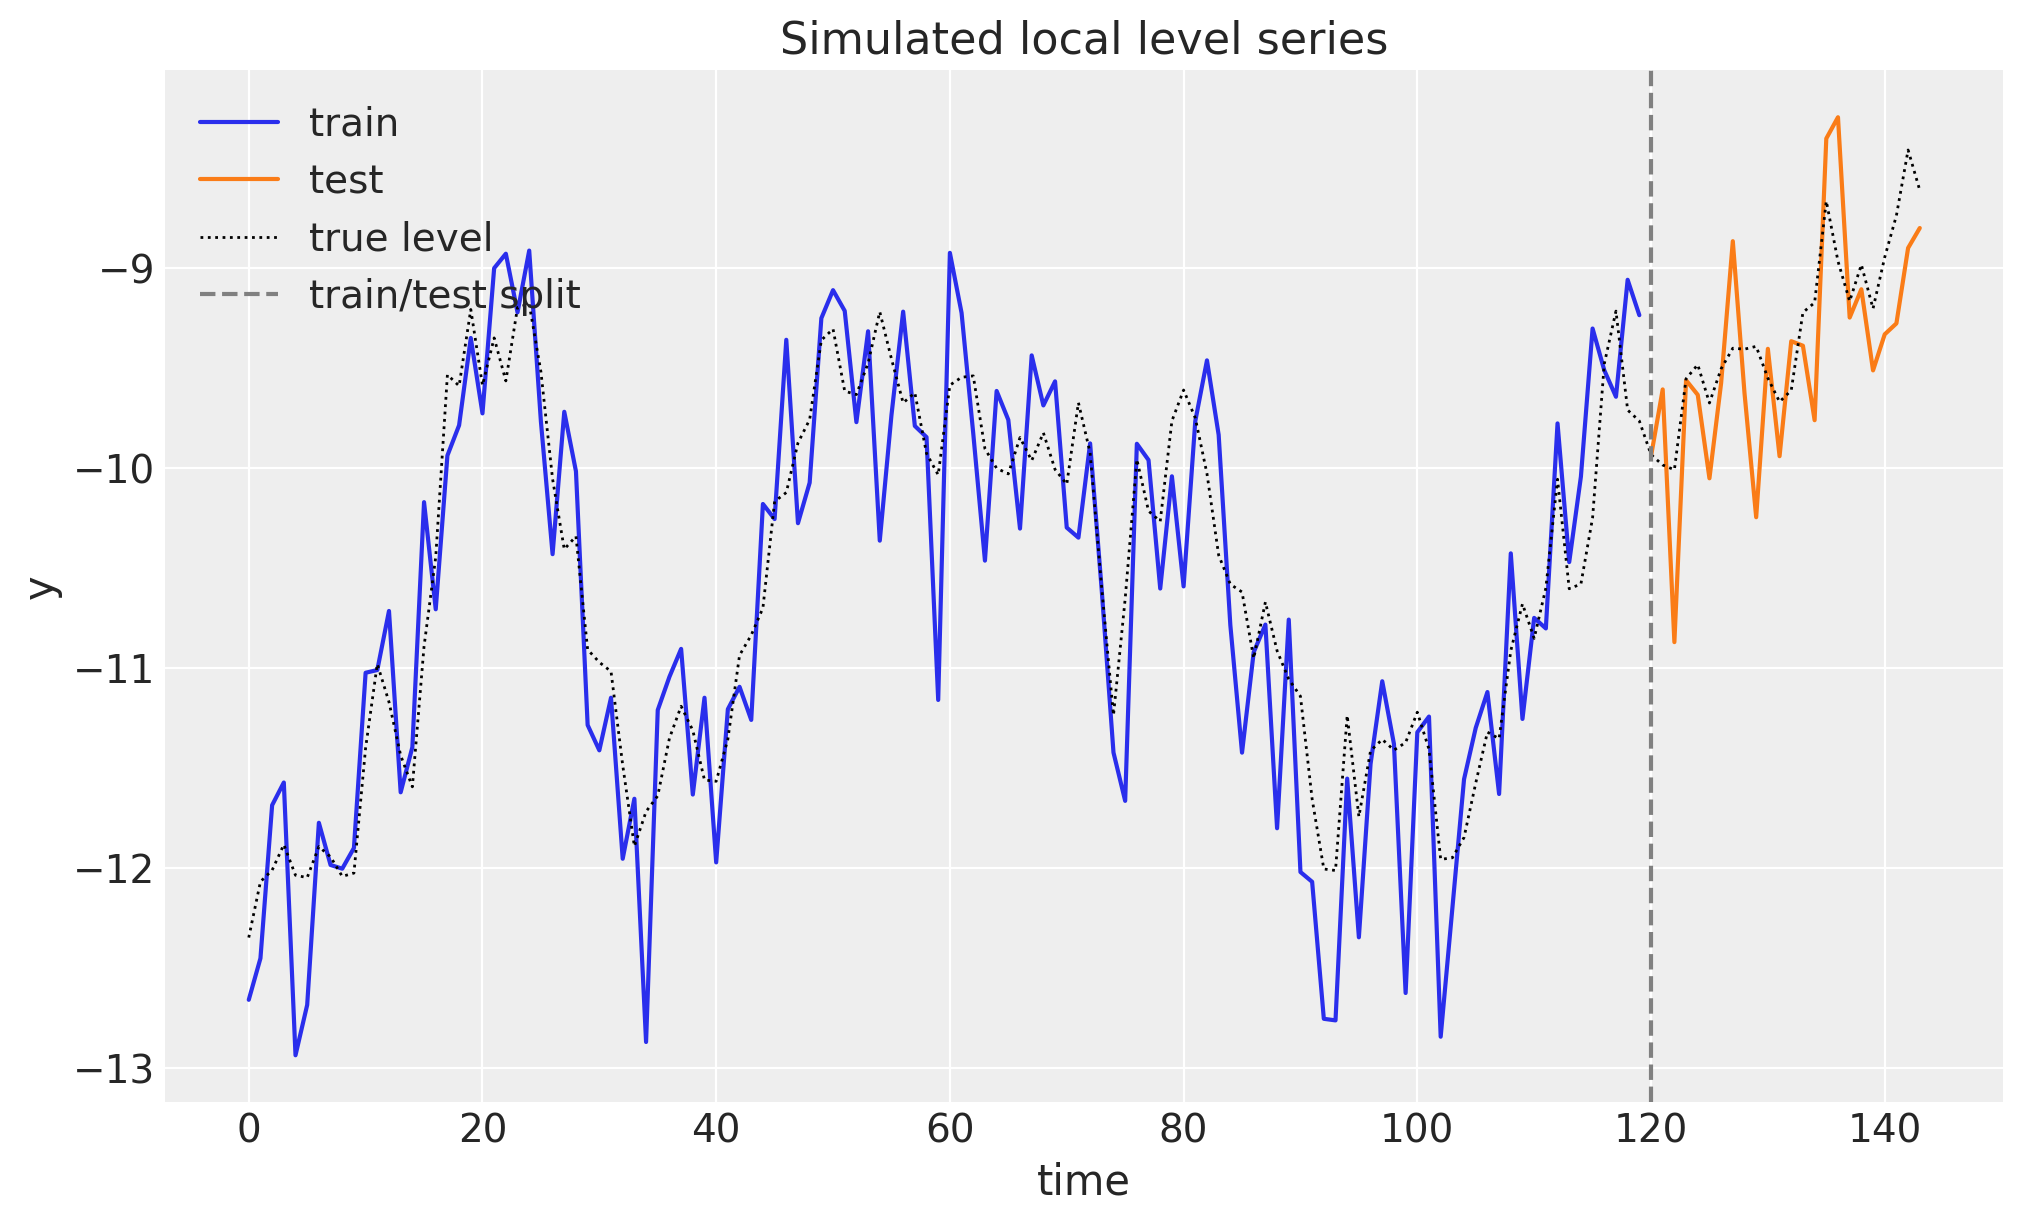

In [4]:
q_true, r_true = 0.3, 0.5
t_obs, future = 120, 24
duration = t_obs + future
time_index = np.arange(duration)
time_grid = np.arange(duration, dtype=np.float32)  # the block's default `times`

rng_key, rng_subkey = random.split(rng_key)
simulated = dsx.simulate(
    local_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true)),
    rng_key=rng_subkey,
    predict_times=jnp.asarray(time_grid),
)
assert simulated.observations is not None and simulated.states is not None  # raw simulation
y_full = simulated.observations[0]  # (duration, 1)
x_true = simulated.states[0, :, 0]  # (duration,)

train_data, test_data = y_full[:t_obs], y_full[t_obs:]
covariates_full = y_full  # the series doubles as the covariate
covariates_train = covariates_full[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_data[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_data[:, 0], color="C1", label="test")
ax.plot(time_index, x_true, color="black", lw=1, ls=":", label="true level")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series", xlabel="time", ylabel="y");

The level wanders as a random walk should, and the observations scatter around it with the larger noise scale $r$.

### Prior Predictive Checks

The priors on both scales are $\text{HalfNormal}(1)$, and the initial level is $\text{Normal}(0, 10)$. Before fitting anything, let's look at the series these priors generate.

For a state space model the prior predictive is a forward simulation. We write a tiny generative model in native `dynestyx` style (`dsx.sample` with `predict_times` only) and run it under a `Simulator` with NumPyro's `Predictive`.

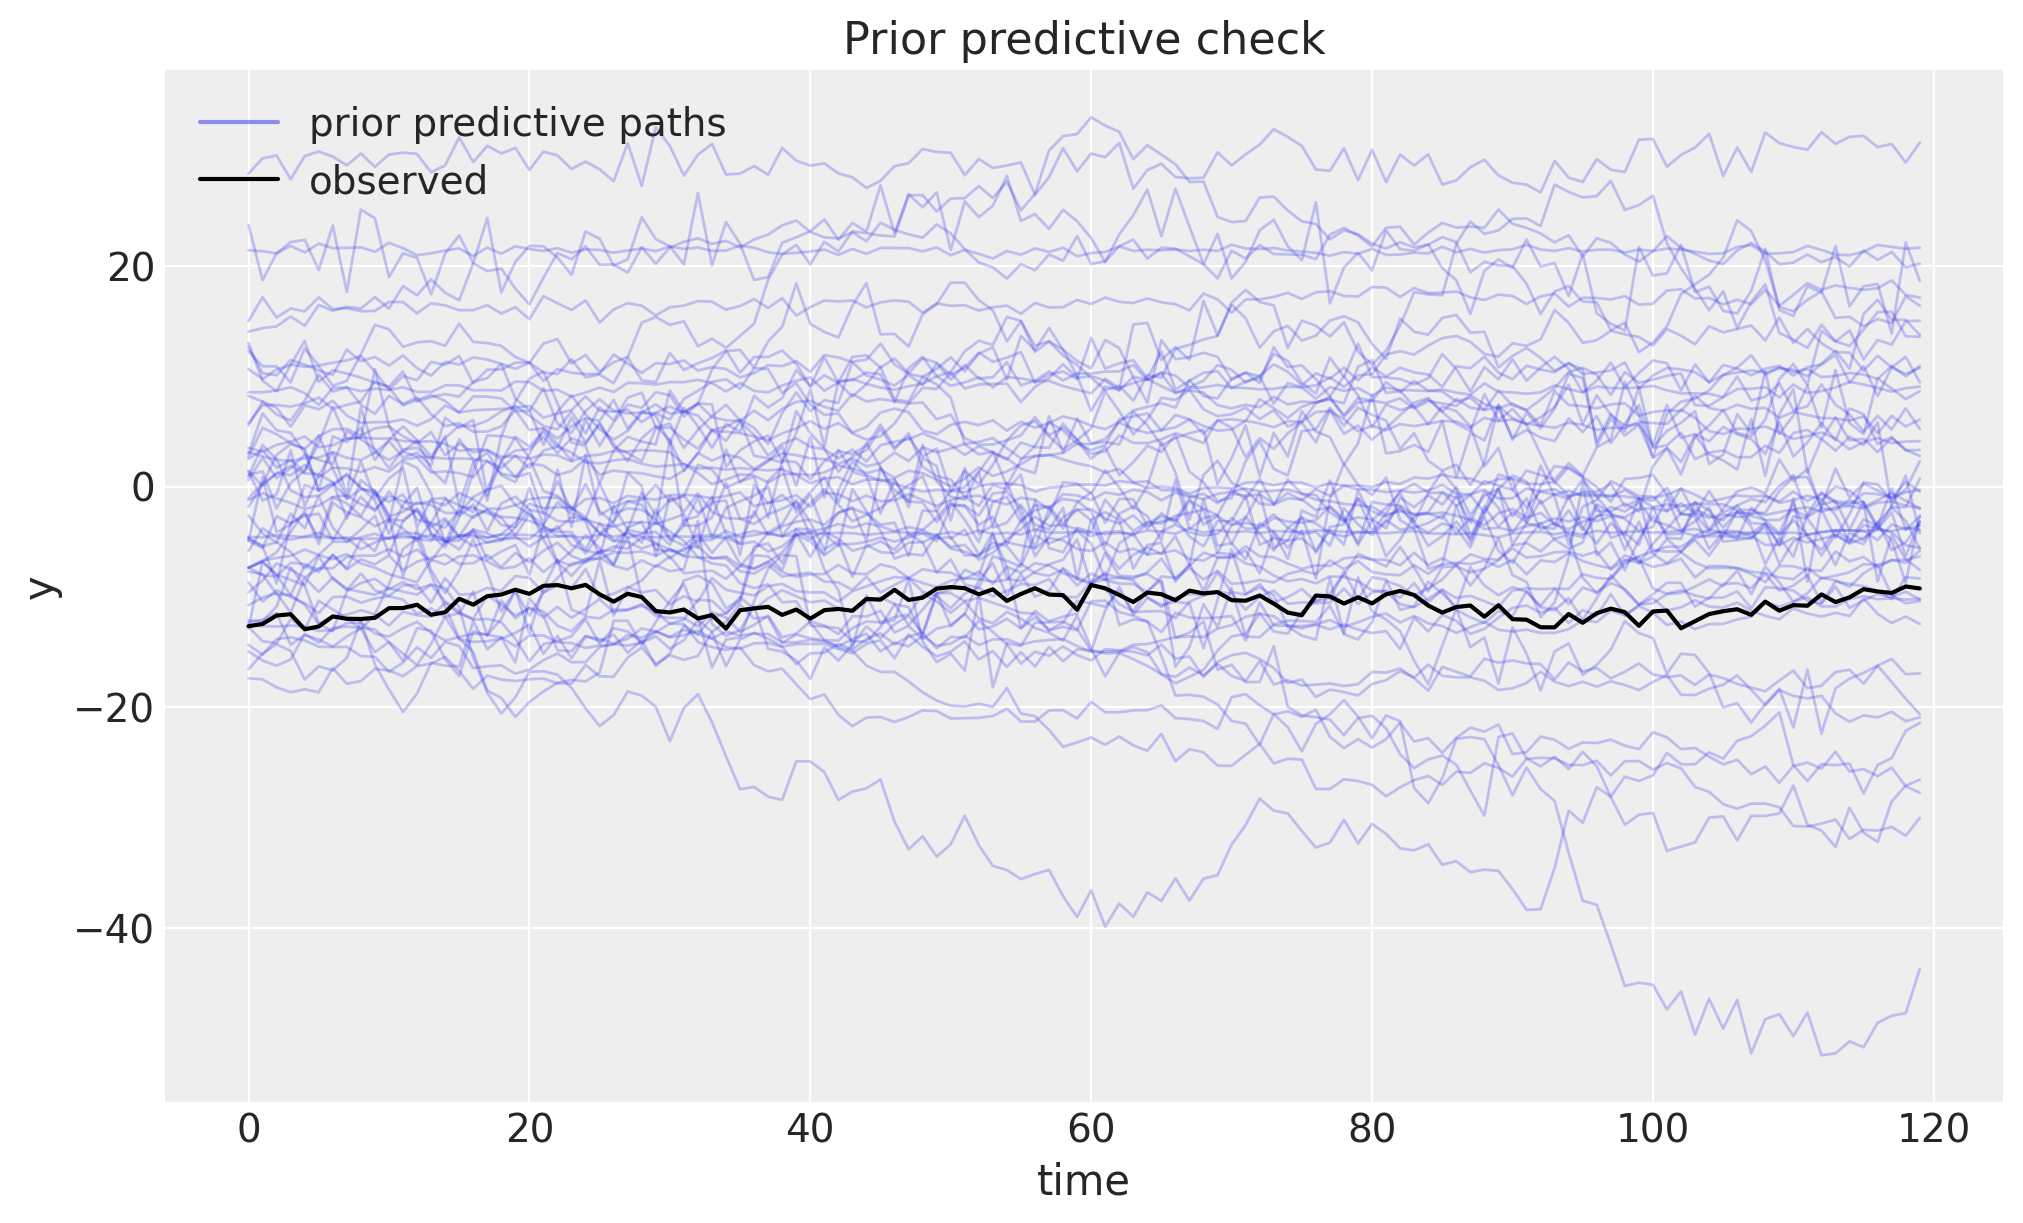

In [5]:
def local_level_prior(predict_times: Array) -> None:
    """Sample the scales from their priors and simulate a path from the local level model."""
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    dsx.sample("f", local_level_dynamics(q, r), predict_times=predict_times)


rng_key, rng_subkey = random.split(rng_key)
with Simulator(n_simulations=1):
    prior_draws = Predictive(local_level_prior, num_samples=50, exclude_deterministic=False)(
        rng_subkey, predict_times=jnp.asarray(time_grid[:t_obs])
    )
prior_paths = np.asarray(prior_draws["f_observations"][:, 0, :, 0])  # (50, t_obs)

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], prior_paths.T, color="C0", alpha=0.25, lw=1)
ax.plot([], [], color="C0", alpha=0.5, label="prior predictive paths")
ax.plot(time_index[:t_obs], train_data[:, 0], color="black", lw=1.5, label="observed")
ax.legend(loc="upper left")
ax.set(title="Prior predictive check", xlabel="time", ylabel="y");

The prior paths cover the observed series comfortably without being absurdly wide, which is good!

### Model Specification

All models are plain NumPyro functions `(covariates, data=None)` with the same priors and the same generative process. They differ only in how the latent level enters the trace.

The **direct** model is the idiomatic `numpyro_forecast` form. [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html) samples one innovation per time step (with a `LocScaleReparam` to soften the funnel between $q$ and the path), the level is their cumulative sum plus the initial level, and [`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html) registers the likelihood. The sampler explores $t_{\text{obs}} + 3$ dimensions.

The two **`dynestyx`** models share one function of the conditioner. With a `LatentPathBuilder` the path is explicit, one sample site of shape $(t_{\text{obs}}, 1)$ plus the two scales. With a `Smoother` the Kalman smoother replaces the path by its exact integral, and the sampler explores $2$ dimensions.

We use `KFSmootherConfig(filter_source="cd_dynamax")`, the exact Rauch-Tung-Striebel smoother on the cheapest backend for a short series on the CPU. The `filter_source="cuthbert"` backend adds support for missing observations and time-varying parameters at a higher cost per gradient.

Note that every model registers a `level` deterministic site when it is called without data. The direct model has its level at hand, and the `dynestyx` models take it from the `x_in_sample` field of the block's result, the in-window state draw behind the in-sample predictive. We read that site further down to compare the three reconstructions of the level.

In [6]:
def local_level_direct(covariates: Array, data: Array | None = None) -> None:
    """Local level model with the innovations sampled explicitly."""
    h = Horizon.from_data(covariates, data)
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    x0 = jnp.asarray(numpyro.sample("x0", dist.Normal(0.0, 10.0)))
    drift = innovations(h, "drift", lambda: dist.Normal(0.0, q), reparam=LocScaleReparam(0))
    level = x0 + jnp.cumsum(drift, axis=-2)
    if h.data is None:
        numpyro.deterministic("level", level)
    predict(h, dist.Normal(0.0, r), level)


def local_level_state_space(conditioner: StateSpaceHandler) -> ForecastModel:
    """Build the local level model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :]  # the observed window travels in the covariates
        q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
        r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
        result = state_space_series(h, "f", y, local_level_dynamics(q, r), conditioner=conditioner)
        if h.data is None:
            numpyro.deterministic("level", result.x_in_sample)

    return model


smoother = Smoother(smoother_config=KFSmootherConfig(filter_source="cd_dynamax"))
local_level_latent = local_level_state_space(LatentPathBuilder())
local_level_smoothed = local_level_state_space(smoother)

### Model Fitting

We run the same sampler budget on the three models: $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps. The `num_steps` extra field records the number of leapfrog steps, that is, gradient evaluations, which is what NUTS spends its time on.

Note that `mcmc.get_samples()` returns the flattened posterior dictionary that the package drivers consume. For the `dynestyx` models it also carries the deterministic sites their handlers record (`f_marginal_loglik`, `f_state_path`, ...).

In [7]:
def fit_nuts(
    rng_key: Array,
    model: ForecastModel,
    data: Array,
    covariates: Array,
    *,
    num_chains: int = 4,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
) -> tuple[MCMC, float]:
    """Fit ``model`` with NUTS and return the sampler and the wall time in seconds."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="sequential",
        progress_bar=False,
    )
    start = time.perf_counter()
    mcmc.run(rng_key, covariates, data, extra_fields=("num_steps",))
    jax.block_until_ready(mcmc.get_samples())
    return mcmc, time.perf_counter() - start


models = {
    "direct (innovations)": local_level_direct,
    "dynestyx, explicit path": local_level_latent,
    "dynestyx, Kalman smoother": local_level_smoothed,
}
fits: dict[str, tuple[MCMC, float]] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    fits[label] = fit_nuts(rng_subkey, model, train_data, covariates_train)
    print(f"{label:>26}: {fits[label][1]:6.1f} s")
posteriors = {label: mcmc.get_samples() for label, (mcmc, _) in fits.items()}

      direct (innovations):   14.8 s


   dynestyx, explicit path:    8.7 s


 dynestyx, Kalman smoother:   12.4 s


### Model Diagnostics

Before looking into the results, let's check some diagnostics. The posteriors of the two scales must agree with each other: the three models define the same joint distribution over $(q, r, y_{1:T})$, and the smoother integrates the level out exactly. What differs is the work the sampler had to do.

We collect the effective sample sizes and $\hat{R}$ with ArviZ (the `(chain, draw)` layout comes from `get_samples(group_by_chain=True)`) next to the wall time and the number of gradient evaluations.

In [8]:
def summarize_fit(mcmc: MCMC, label: str, wall: float) -> pd.DataFrame:
    """One-row table of posterior means, diagnostics and sampler cost for ``q`` and ``r``."""
    grouped = mcmc.get_samples(group_by_chain=True)
    tree = az.from_dict({"posterior": {name: np.asarray(grouped[name]) for name in ("q", "r")}})
    summary = az.summary(tree, var_names=["q", "r"])
    num_steps = int(np.asarray(mcmc.get_extra_fields(group_by_chain=True)["num_steps"]).sum())
    return pd.DataFrame(
        {
            "q mean": [summary.loc["q", "mean"]],
            "q sd": [summary.loc["q", "sd"]],
            "r mean": [summary.loc["r", "mean"]],
            "r sd": [summary.loc["r", "sd"]],
            "ess_bulk q": [summary.loc["q", "ess_bulk"]],
            "ess_bulk r": [summary.loc["r", "ess_bulk"]],
            "r_hat q": [summary.loc["q", "r_hat"]],
            "r_hat r": [summary.loc["r", "r_hat"]],
            "leapfrog steps": [num_steps],
            "wall time (s)": [wall],
        },
        index=[label],
    )


comparison = pd.concat([summarize_fit(mcmc, label, wall) for label, (mcmc, wall) in fits.items()])
print(f"truth: q = {q_true}, r = {r_true}")
comparison.round({"q mean": 3, "q sd": 3, "r mean": 3, "r sd": 3, "r_hat q": 3, "r_hat r": 3})

truth: q = 0.3, r = 0.5


,q mean,q sd,r mean,r sd,ess_bulk q,ess_bulk r,r_hat q,r_hat r,leapfrog steps,wall time (s)
direct (innovations),0.388,0.059,0.441,0.05,875,798,1.00,1.00,1019459,14.823331
"dynestyx, explicit path",0.389,0.064,0.441,0.054,593,967,1.01,1.01,65648,8.704117
"dynestyx, Kalman smoother",0.389,0.063,0.44,0.052,1525,1699,1.00,1.00,18062,12.393678


The three posterior means agree to two decimals and the $\hat{R}$ values are at most $1.01$, which is good! All three fits place the true values inside their bulk. With $120$ observations the scales are only moderately well identified, so a posterior mean one to one and a half standard deviations away from the truth is not surprising.

The smoothed model reaches the largest effective sample size with a small fraction of the gradient evaluations. It moves in a $2$-dimensional posterior instead of a $123$-dimensional one whose geometry couples $q$ to every innovation.

The explicit path built by `dynestyx` sits in between the two. It needs fewer gradients than the direct model but mixes less well on $q$, since its path site has no reparameterization equivalent to `LocScaleReparam` yet.

Each smoother gradient is more expensive (a Kalman pass over the window instead of a sum of Gaussian log densities), so on a short series on the CPU the wall times end up in the same range. The advantage grows with the length of the series, since the direct posterior grows with it while the smoother's cost is linear in it and leaves the sampler's geometry untouched. It also grows on accelerators, where the parallel-in-time scan of the `cuthbert` backend pays off.

Next, let's overlay the three posteriors of the two scales.

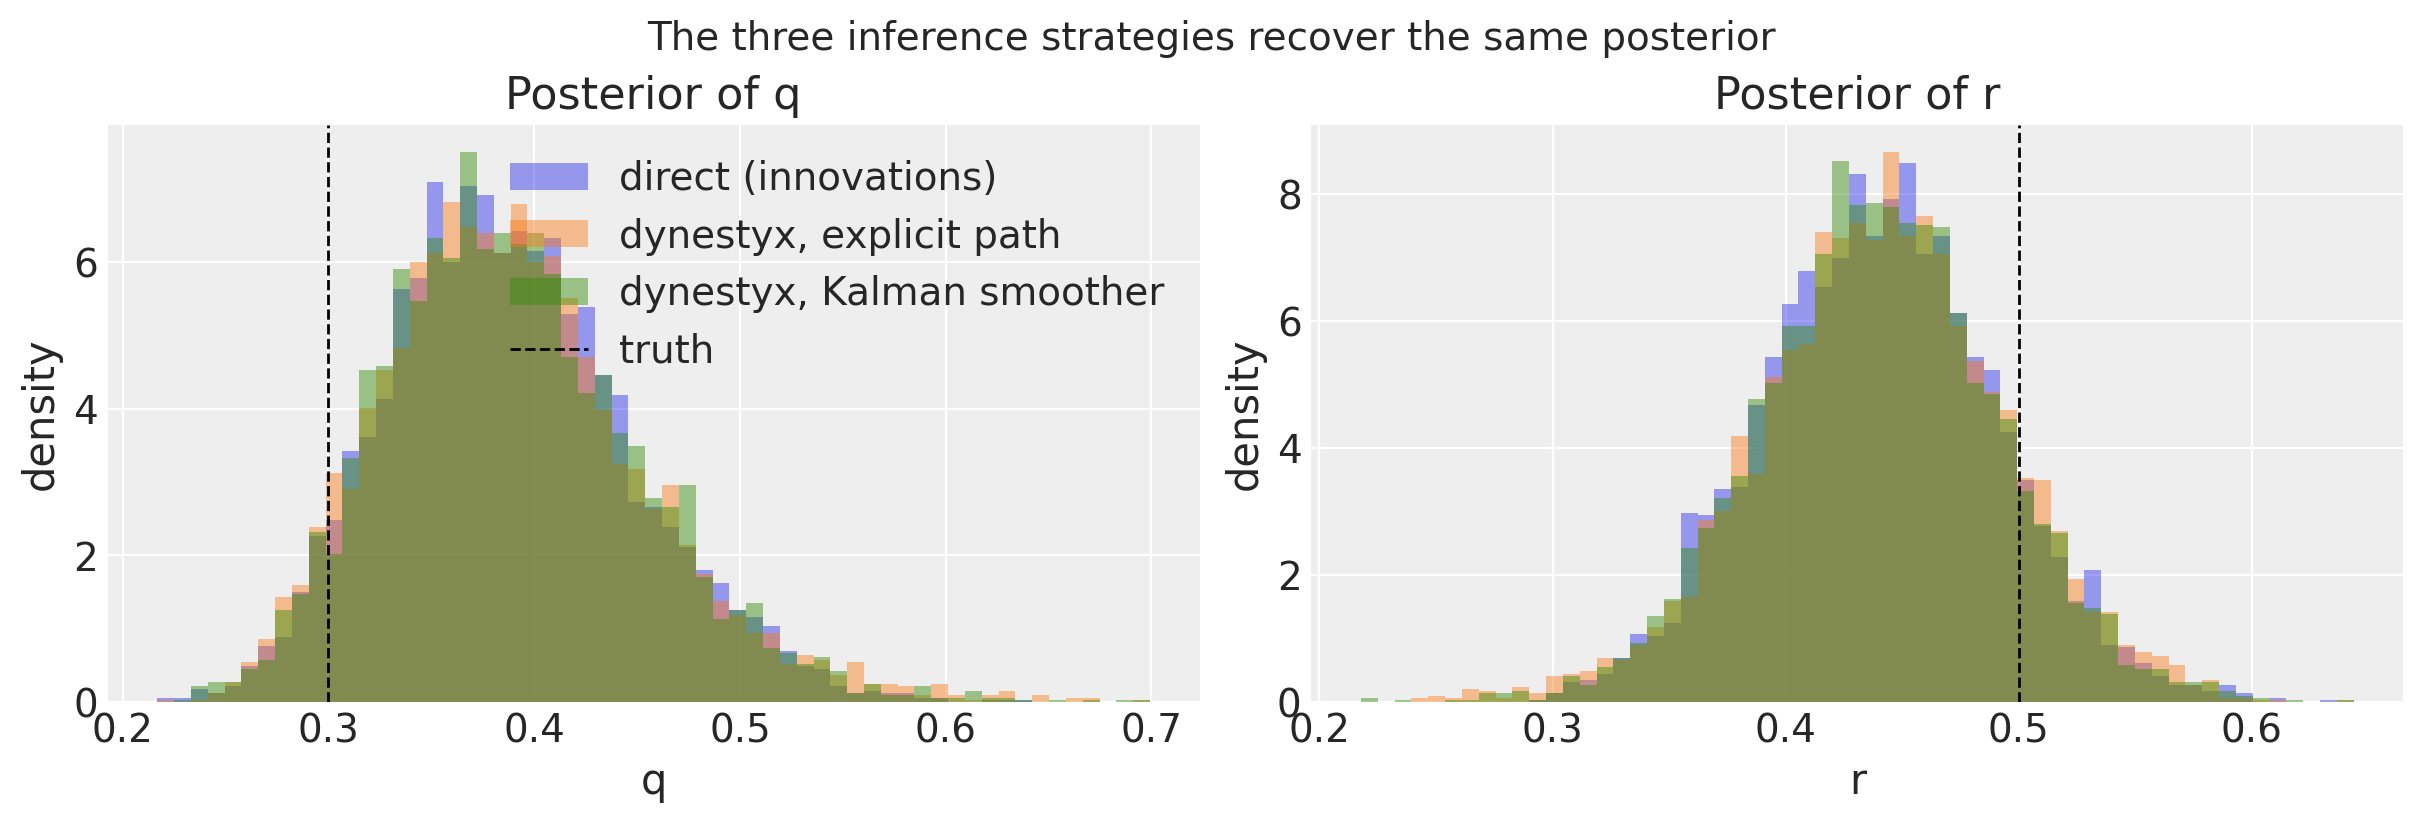

In [9]:
colors = {label: f"C{i}" for i, label in enumerate(models)}
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for ax, name, truth in zip(axes, ("q", "r"), (q_true, r_true), strict=True):
    values = {label: np.asarray(post[name]) for label, post in posteriors.items()}
    bins = np.linspace(
        min(v.min() for v in values.values()), max(v.max() for v in values.values()), 60
    )
    for label, v in values.items():
        ax.hist(v, bins=bins, density=True, alpha=0.45, color=colors[label], label=label)
    ax.axvline(truth, color="black", ls="--", lw=1, label="truth")
    ax.set(title=f"Posterior of {name}", xlabel=name, ylabel="density")
axes[0].legend(loc="upper right")
fig.suptitle("The three inference strategies recover the same posterior", fontsize=14);

The three histograms lie on top of each other, and the truth sits inside the bulk of each posterior.

### Forecast

Forecasting is the package's [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html) driver in all three cases. It runs `Predictive` over the full-horizon covariates and returns the `"forecast"` site with one path per posterior draw.

For the direct model the in-sample innovations are replayed from the posterior and the future ones are drawn from the prior. For the `dynestyx` models every draw re-conditions on the training window with its own $(q, r)$ (the smoother recomputes the smoothing distribution, the builder reconstructs the posterior path), and the simulator rolls the conditioned state forward.

Note that the re-conditioning is one vectorized pass over the window per draw, which is cheap here. For long windows or particle filters, the design document records a cached-anchor rollout as the fallback.

The driver is jitted and vectorized over the draws, and the `dynestyx` handlers inside the model run under that `jit` and `vmap` without any special treatment. We define two small helpers for the HDI bands and their labels, then forecast with the three posteriors.

In [10]:
def hdi_over_draws(draws: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    """Lower and upper HDI bounds over the sample axis of ``(sample, time, 1)`` draws."""
    da = xr.DataArray(np.asarray(draws)[..., 0], dims=["sample", "time"])
    hdi = az.hdi(da, prob=prob, dim="sample")  # (time, ci_bound)
    return hdi.sel(ci_bound="lower").to_numpy(), hdi.sel(ci_bound="upper").to_numpy()


def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = {0.5: 0.6, 0.94: 0.3}  # 50% band darker, 94% band lighter

forecasts: dict[str, Array | np.ndarray] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    forecasts[label] = forecast(rng_subkey, model, posteriors[label], train_data, covariates_full)
    print(f"{label:>26}: forecast draws {forecasts[label].shape}")

      direct (innovations): forecast draws (4000, 24, 1)


   dynestyx, explicit path: forecast draws (4000, 24, 1)


 dynestyx, Kalman smoother: forecast draws (4000, 24, 1)


Let's plot the three forecast fans with their $50\%$ and $94\%$ HDI bands.

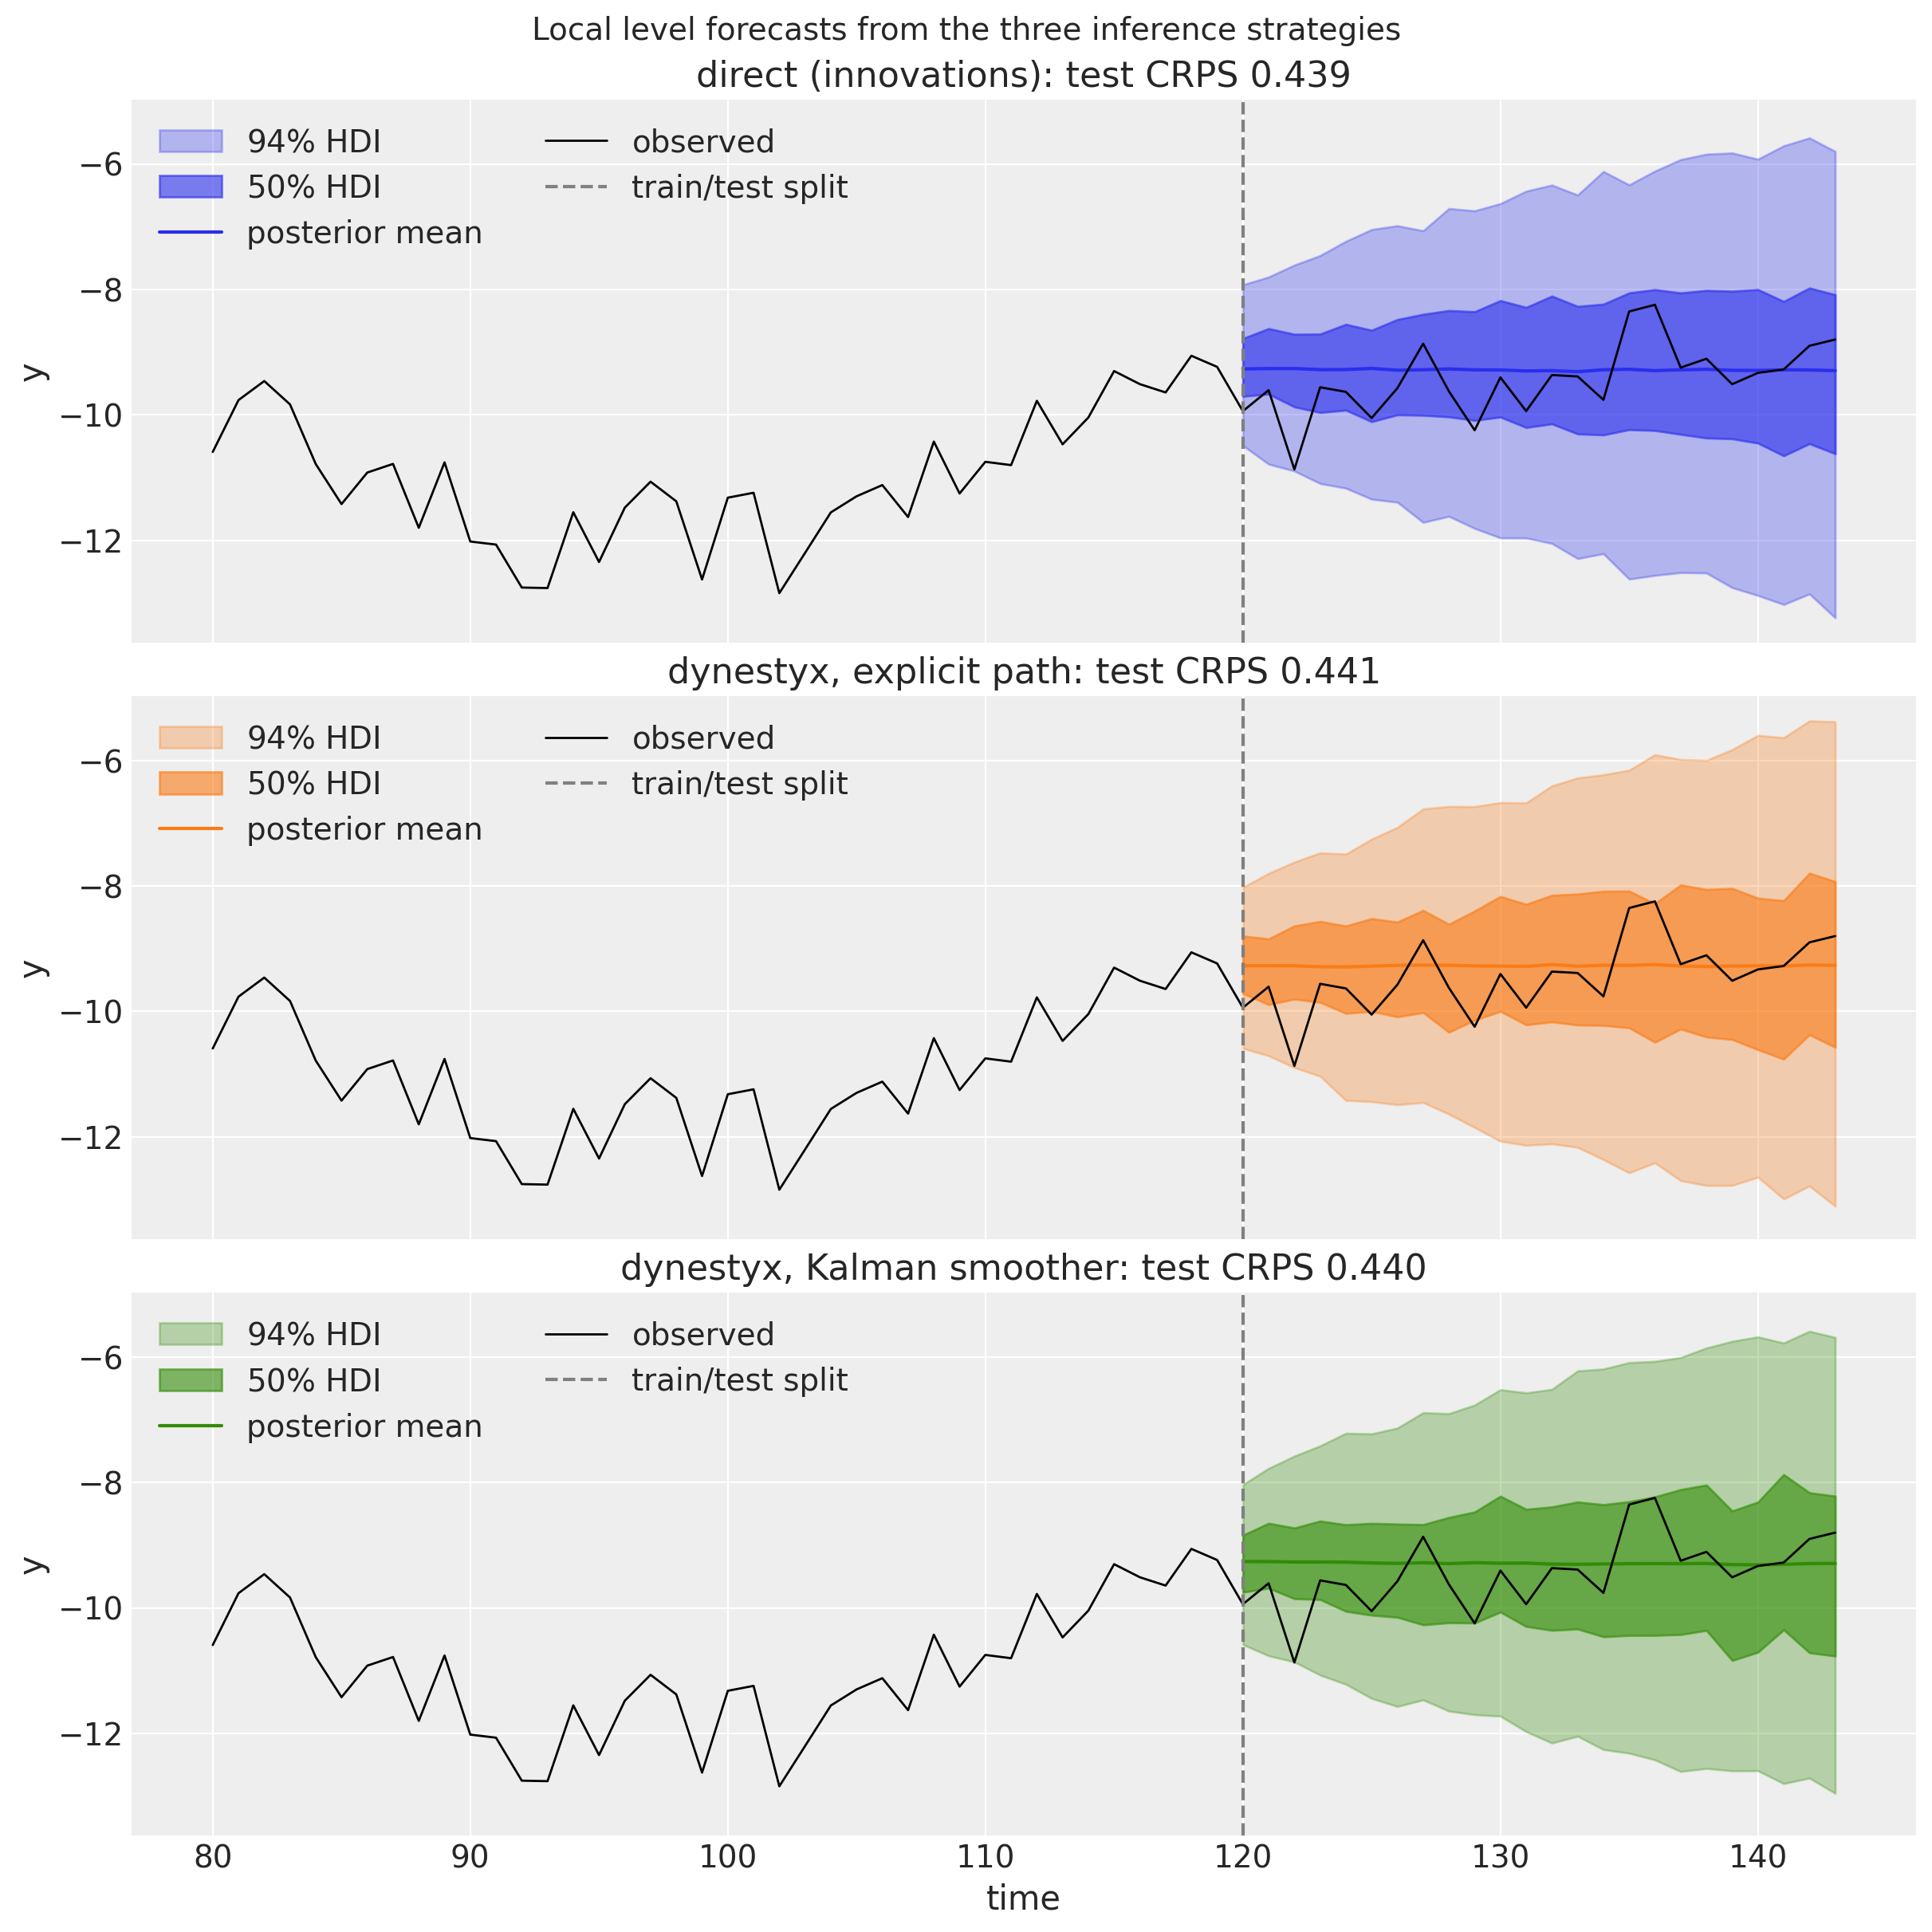

In [11]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
future_index = time_index[t_obs:]
for ax, (label, draws) in zip(axes, forecasts.items(), strict=True):
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(draws, prob)
        ax.fill_between(
            future_index, lower, upper, color=color, alpha=hdi_alphas[prob], label=hdi_label(prob)
        )
    ax.plot(
        future_index, np.asarray(draws).mean(axis=0)[:, 0], color=color, label="posterior mean"
    )
    ax.plot(
        time_index[t_obs - 40 :], y_full[t_obs - 40 :, 0], color="black", lw=1, label="observed"
    )
    ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
    crps = eval_crps(draws, test_data)
    ax.set(title=f"{label}: test CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="upper left", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("Local level forecasts from the three inference strategies", fontsize=14);

The three fans are the same forecast up to Monte Carlo error, which is the point of the exercise! The `dynestyx` models are not approximations of the direct one. They are the same model with a different parameterization for the sampler.

The same comparison in tabular form: point accuracy through MAE and RMSE, the CRPS as a proper score for the whole predictive distribution, and the empirical coverage of the central $50\%$ and $94\%$ intervals.

In [12]:
metric_fns = {
    "MAE": eval_mae,
    "RMSE": eval_rmse,
    "CRPS": eval_crps,
    "coverage (50%)": partial(eval_coverage, alpha=0.5),
    "coverage (94%)": partial(eval_coverage, alpha=0.94),
}
pd.DataFrame(
    {
        label: {name: float(fn(draws, test_data)) for name, fn in metric_fns.items()}
        for label, draws in forecasts.items()
    }
).round(3)

,direct (innovations),"dynestyx, explicit path","dynestyx, Kalman smoother"
MAE,0.449,0.449,0.447
RMSE,0.591,0.586,0.591
CRPS,0.439,0.441,0.440
coverage (50%),0.833,0.833,0.833
coverage (94%),1.000,1.000,1.000


The metrics on the held-out window agree accordingly.

### Posterior Predictive Checks

As our models and posterior samples are looking good, we can now look into the in-sample posterior predictive checks. Because the observed window travels in the covariates, the package's [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html) applies to the `dynestyx` models as it does to any other. It restores the `(chain, draw)` structure, samples the in-sample posterior predictive by calling the model without data, and, because we hand it the full-horizon covariates, runs the forecast into the `predictions` group.

Recall that `data=None` is a mode switch. The window still reaches the model through the covariates, so the in-sample predictive is the smoothing predictive $p(y_t^{\text{rep}} \mid y_{1:T}, \theta)$ and not a prior predictive.

The three models produce it in three ways. The direct model replays its sampled path and adds observation noise. Under the `LatentPathBuilder` the block takes the posterior path that `dynestyx` reconstructs and adds the same noise. Under the `Smoother` the block draws every in-window state from the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ and adds the noise. Marginally at every step, these are the same quantity.

In [13]:
trees: dict[str, xr.DataTree] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    trees[label] = to_datatree(
        rng_subkey, model, posteriors[label], train_data, covariates_full, num_chains=4
    )
trees["dynestyx, Kalman smoother"]

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:                           (chain: 4, draw: 1000,
│                                              f_smoothed_states_cov_dim_0: 120,
│                                              f_smoothed_states_cov_dim_1: 1,
│                                              f_smoothed_states_cov_dim_2: 1,
│                                              f_smoothed_states_cov_diag_dim_0: 120,
│                                              f_smoothed_states_cov_diag_dim_1: 1,
│                                              f_smoothed_states_mean_dim_0: 120,
│                                              f_smoothed_states_mean_dim_1: 1)
│       Coordinates:
│         * chain                             (chain) int64 32B 0 1 2 3
│         * draw                              (draw) int64 8kB 0 1 2 3 ... 997 998 999
│         * f_smoothed_states_cov_dim_0       (f_smoothed_states_cov_dim_0) int64 960B ...
│         * f_smoothed_states_cov_dim_1       (f_smoothed_states_cov_dim_1) int64 8B 0
│         * f_smoothed_states_cov_dim_2       (f_smoothed_states_cov_dim_2) int64 8B 0
│         * f_smoothed_states_cov_diag_dim_0  (f_smoothed_states_cov_diag_dim_0) int64 960B ...
│         * f_smoothed_states_cov_diag_dim_1  (f_smoothed_states_cov_diag_dim_1) int64 8B ...
│         * f_smoothed_states_mean_dim_0      (f_smoothed_states_mean_dim_0) int64 960B ...
│         * f_smoothed_states_mean_dim_1      (f_smoothed_states_mean_dim_1) int64 8B 0
│       Data variables:
│           f_marginal_loglik                 (chain, draw) float32 16kB -125.2 ... -...
│           f_smoothed_states_cov             (chain, draw, f_smoothed_states_cov_dim_0, f_smoothed_states_cov_dim_1, f_smoothed_states_cov_dim_2) float32 2MB ...
│           f_smoothed_states_cov_diag        (chain, draw, f_smoothed_states_cov_diag_dim_0, f_smoothed_states_cov_diag_dim_1) float32 2MB ...
│           f_smoothed_states_mean            (chain, draw, f_smoothed_states_mean_dim_0, f_smoothed_states_mean_dim_1) float32 2MB ...
│           q                                 (chain, draw) float32 16kB 0.3989 ... 0...
│           r                                 (chain, draw) float32 16kB 0.3879 ... 0...
│       Attributes:
│           created_at:                 2026-09-18T12:38:25.147386+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 120, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 2MB -12.41 -11.91 ... -9.207
│       Attributes:
│           created_at:                 2026-09-18T12:38:25.646251+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 120, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 480B -12.66 -12.45 -11.69 ... -9.059 -9.236
│       Attributes:
│           created_at:                 2026-09-18T12:38:25.646515+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_libra

The tree carries the `posterior`, `posterior_predictive`, `observed_data` and `predictions` groups, as for any other model of the package. Let's plot the three in-sample bands.

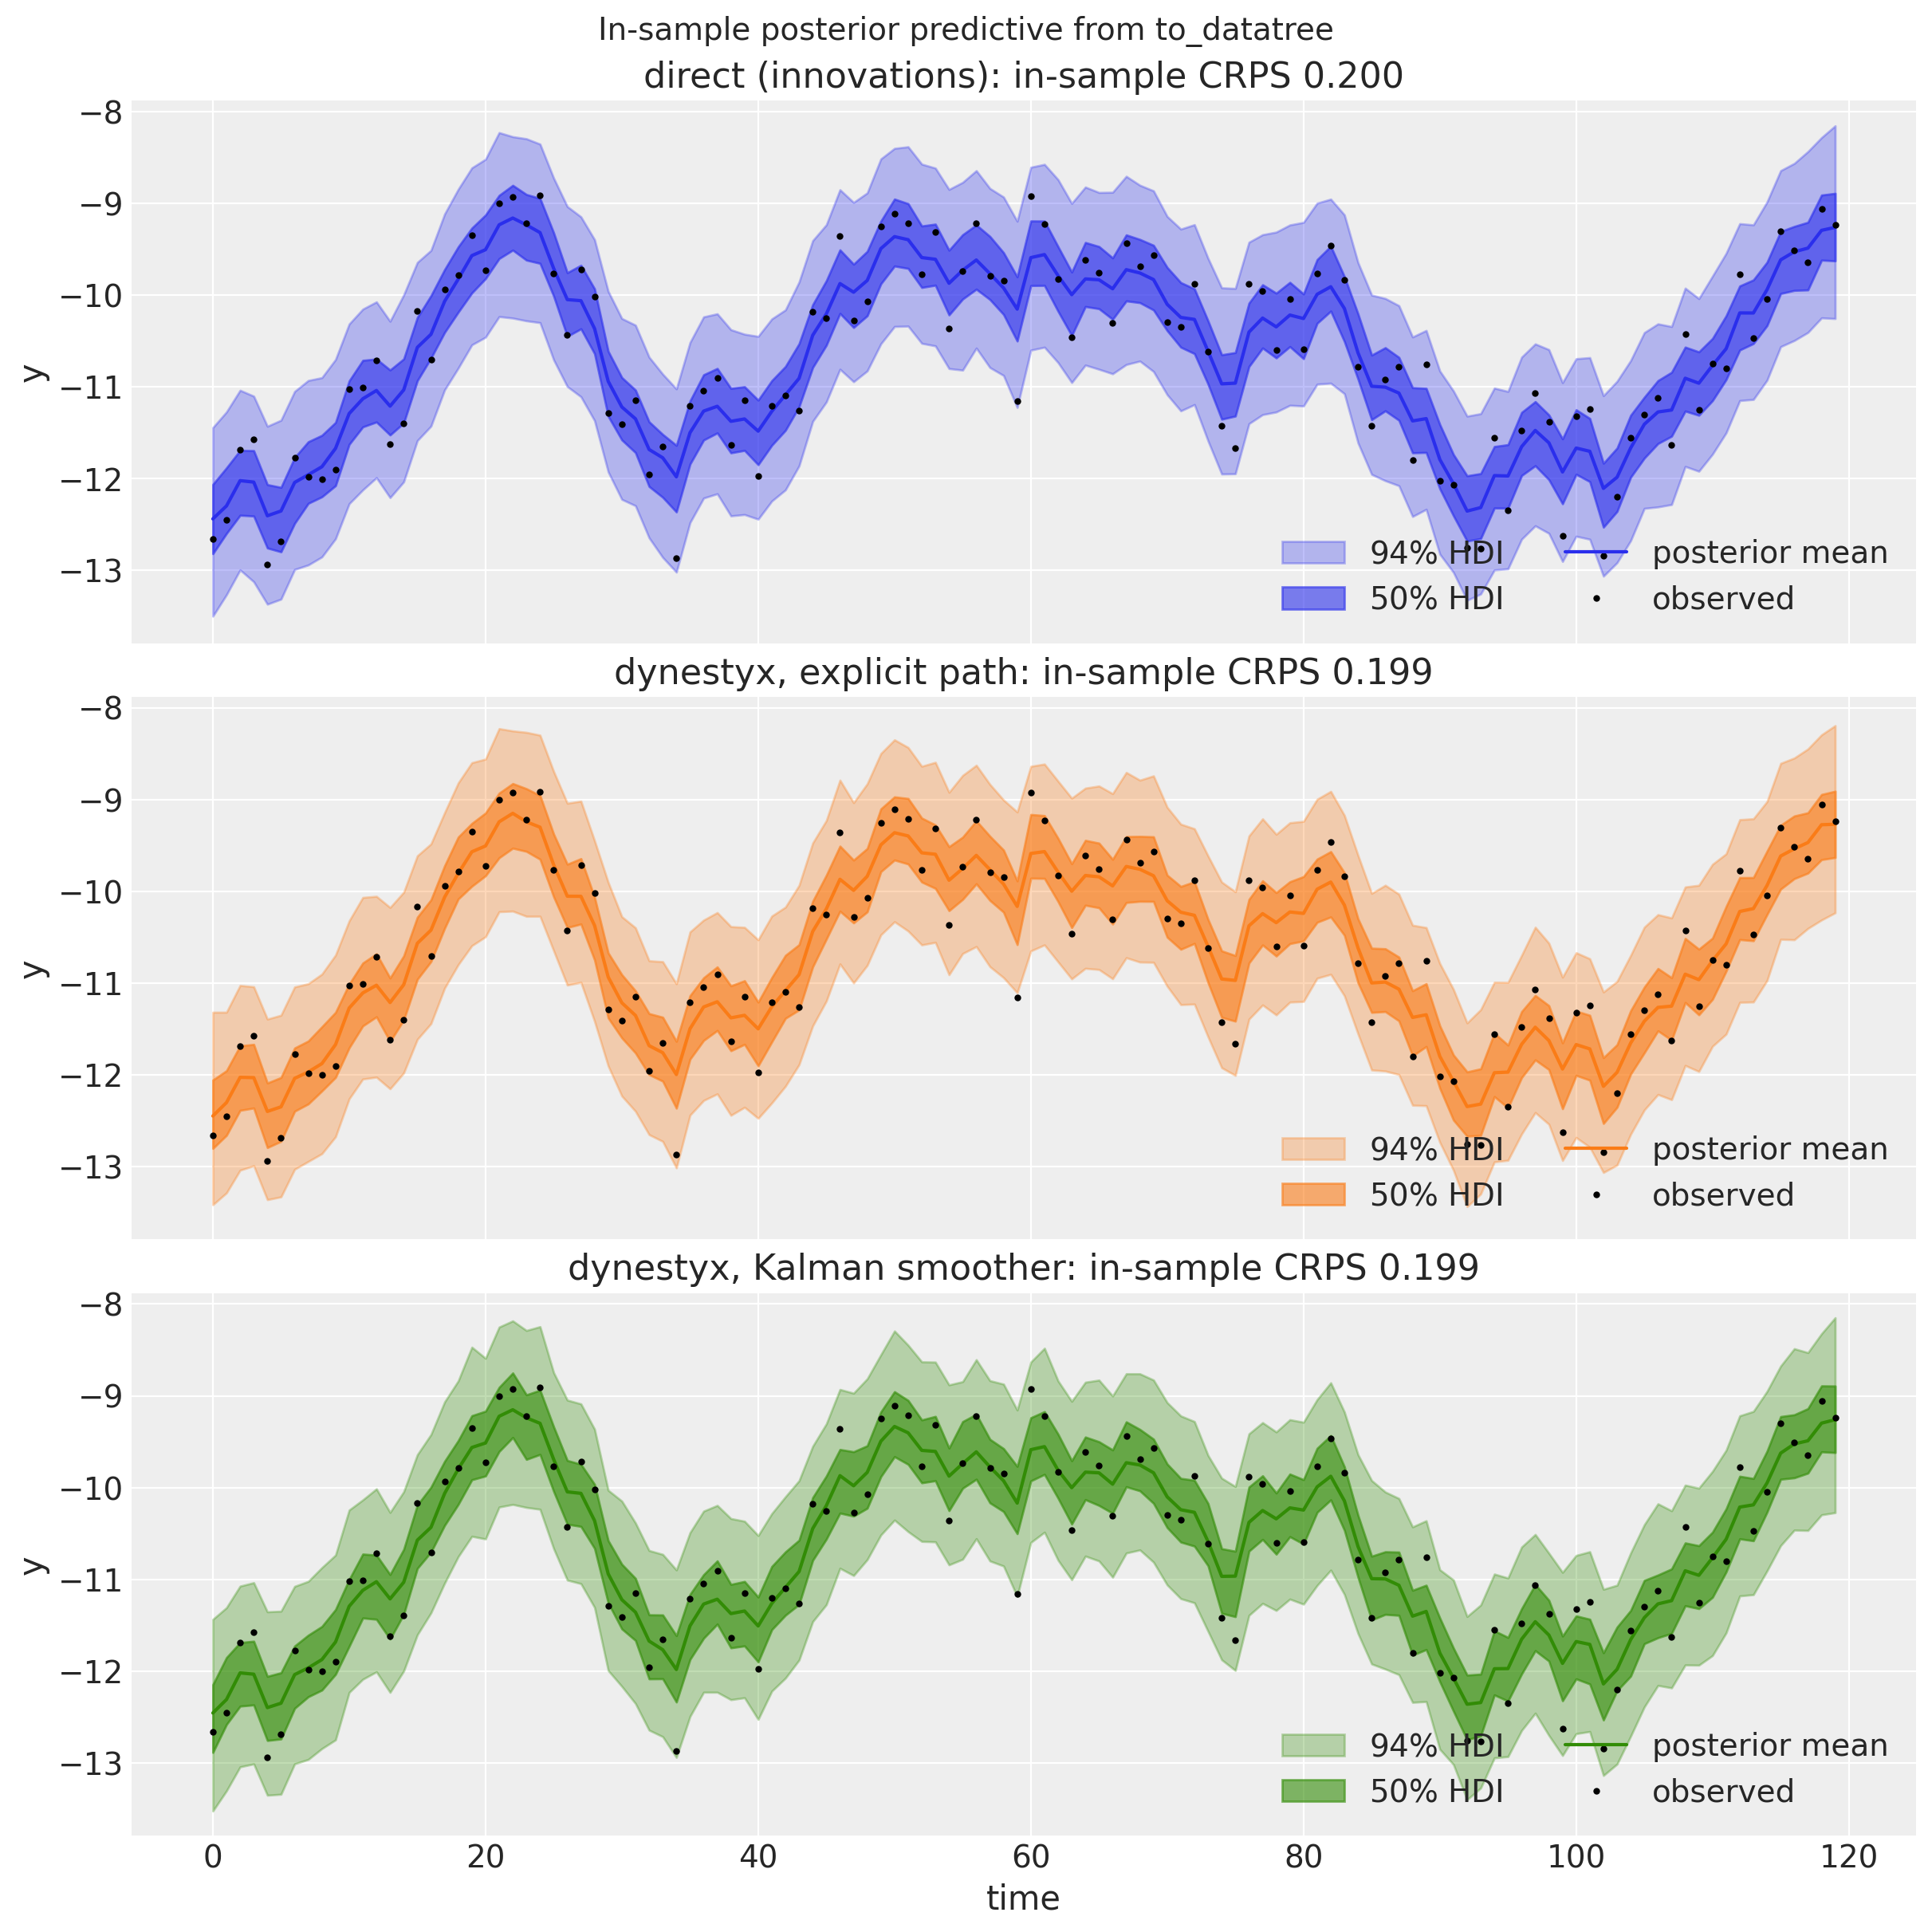

In [14]:
def stacked_draws(tree: xr.DataTree, group: str, var: str) -> np.ndarray:
    """Stack the ``(chain, draw)`` dims of ``tree[group][var]`` into a leading sample axis."""
    return (
        tree[group]
        .dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
for ax, (label, tree) in zip(axes, trees.items(), strict=True):
    in_sample = stacked_draws(tree, "posterior_predictive", "obs")
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(in_sample, prob)
        ax.fill_between(
            time_index[:t_obs],
            lower,
            upper,
            color=color,
            alpha=hdi_alphas[prob],
            label=hdi_label(prob),
        )
    ax.plot(time_index[:t_obs], in_sample.mean(axis=0)[:, 0], color=color, label="posterior mean")
    ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="black", ms=4, label="observed")
    crps = eval_crps(in_sample, train_data)
    ax.set(title=f"{label}: in-sample CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="lower right", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("In-sample posterior predictive from to_datatree", fontsize=14);

The three bands coincide and the in-sample CRPS values agree to the third decimal. The `LatentPathBuilder` conditioner serves the in-sample predictive as well as the smoother does, so both `dynestyx` strategies plug into `predict_in_sample` and `to_datatree`.

### Latent Level Reconstruction

The smoothing distribution is what makes the in-sample predictive possible, and it is worth seeing why a `Filter` cannot serve the same purpose. The filtering distribution $p(x_t \mid y_{1:t}, \theta)$ uses the observations up to step $t$ only, so it lags the level and is wider at the start of the window, where little has been seen. The smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ uses the whole window.

Recall that every model registers a `level` site when it is called without data. Calling `Predictive` with the posterior draws and the training covariates only, and asking for that site, gives one level path per posterior draw. The direct model replays `x0` plus the cumulative sum of the sampled `drift`, the builder returns its posterior path and the smoother draws from the smoothing distribution, the last two through the same `x_in_sample` field of the block's result.

The filtered level takes one more step, since a `Filter` conditioner has no in-sample mode. `dynestyx` lets us re-interpret the smoother's posterior under a `Filter` handler with `Predictive`, which records the `f_filtered_states_*` sites without any refitting. This is the separation between model and inference that the handlers are designed for. Drawing one level per posterior draw from those per-step Gaussians mixes the state uncertainty and the parameter uncertainty into a single band, as the `level` site does for the other three.

In [15]:
levels: dict[str, np.ndarray] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    level_site = Predictive(model, posterior_samples=posteriors[label], return_sites=["level"])
    levels[label] = np.asarray(level_site(rng_subkey, covariates_train)["level"])
    print(f"{label:>26}: level draws {levels[label].shape}")

local_level_filtered = local_level_state_space(Filter(filter_config=KFConfig()))
rng_key, key_sites, key_draw = random.split(rng_key, 3)
filtered_sites = Predictive(
    local_level_filtered,
    posterior_samples=posteriors["dynestyx, Kalman smoother"],
    return_sites=["f_filtered_states_mean", "f_filtered_states_cov_diag"],
)(key_sites, covariates_train, train_data)
filtered_mean = np.asarray(filtered_sites["f_filtered_states_mean"])
filtered_sd = np.sqrt(np.asarray(filtered_sites["f_filtered_states_cov_diag"]))
filtered_level = filtered_mean + filtered_sd * np.asarray(
    random.normal(key_draw, filtered_mean.shape)
)

      direct (innovations): level draws (4000, 120, 1)
   dynestyx, explicit path: level draws (4000, 120, 1)


 dynestyx, Kalman smoother: level draws (4000, 120, 1)


Let's plot the filtered and smoothed levels in the top panel, and the three `level` sites in the bottom panel.

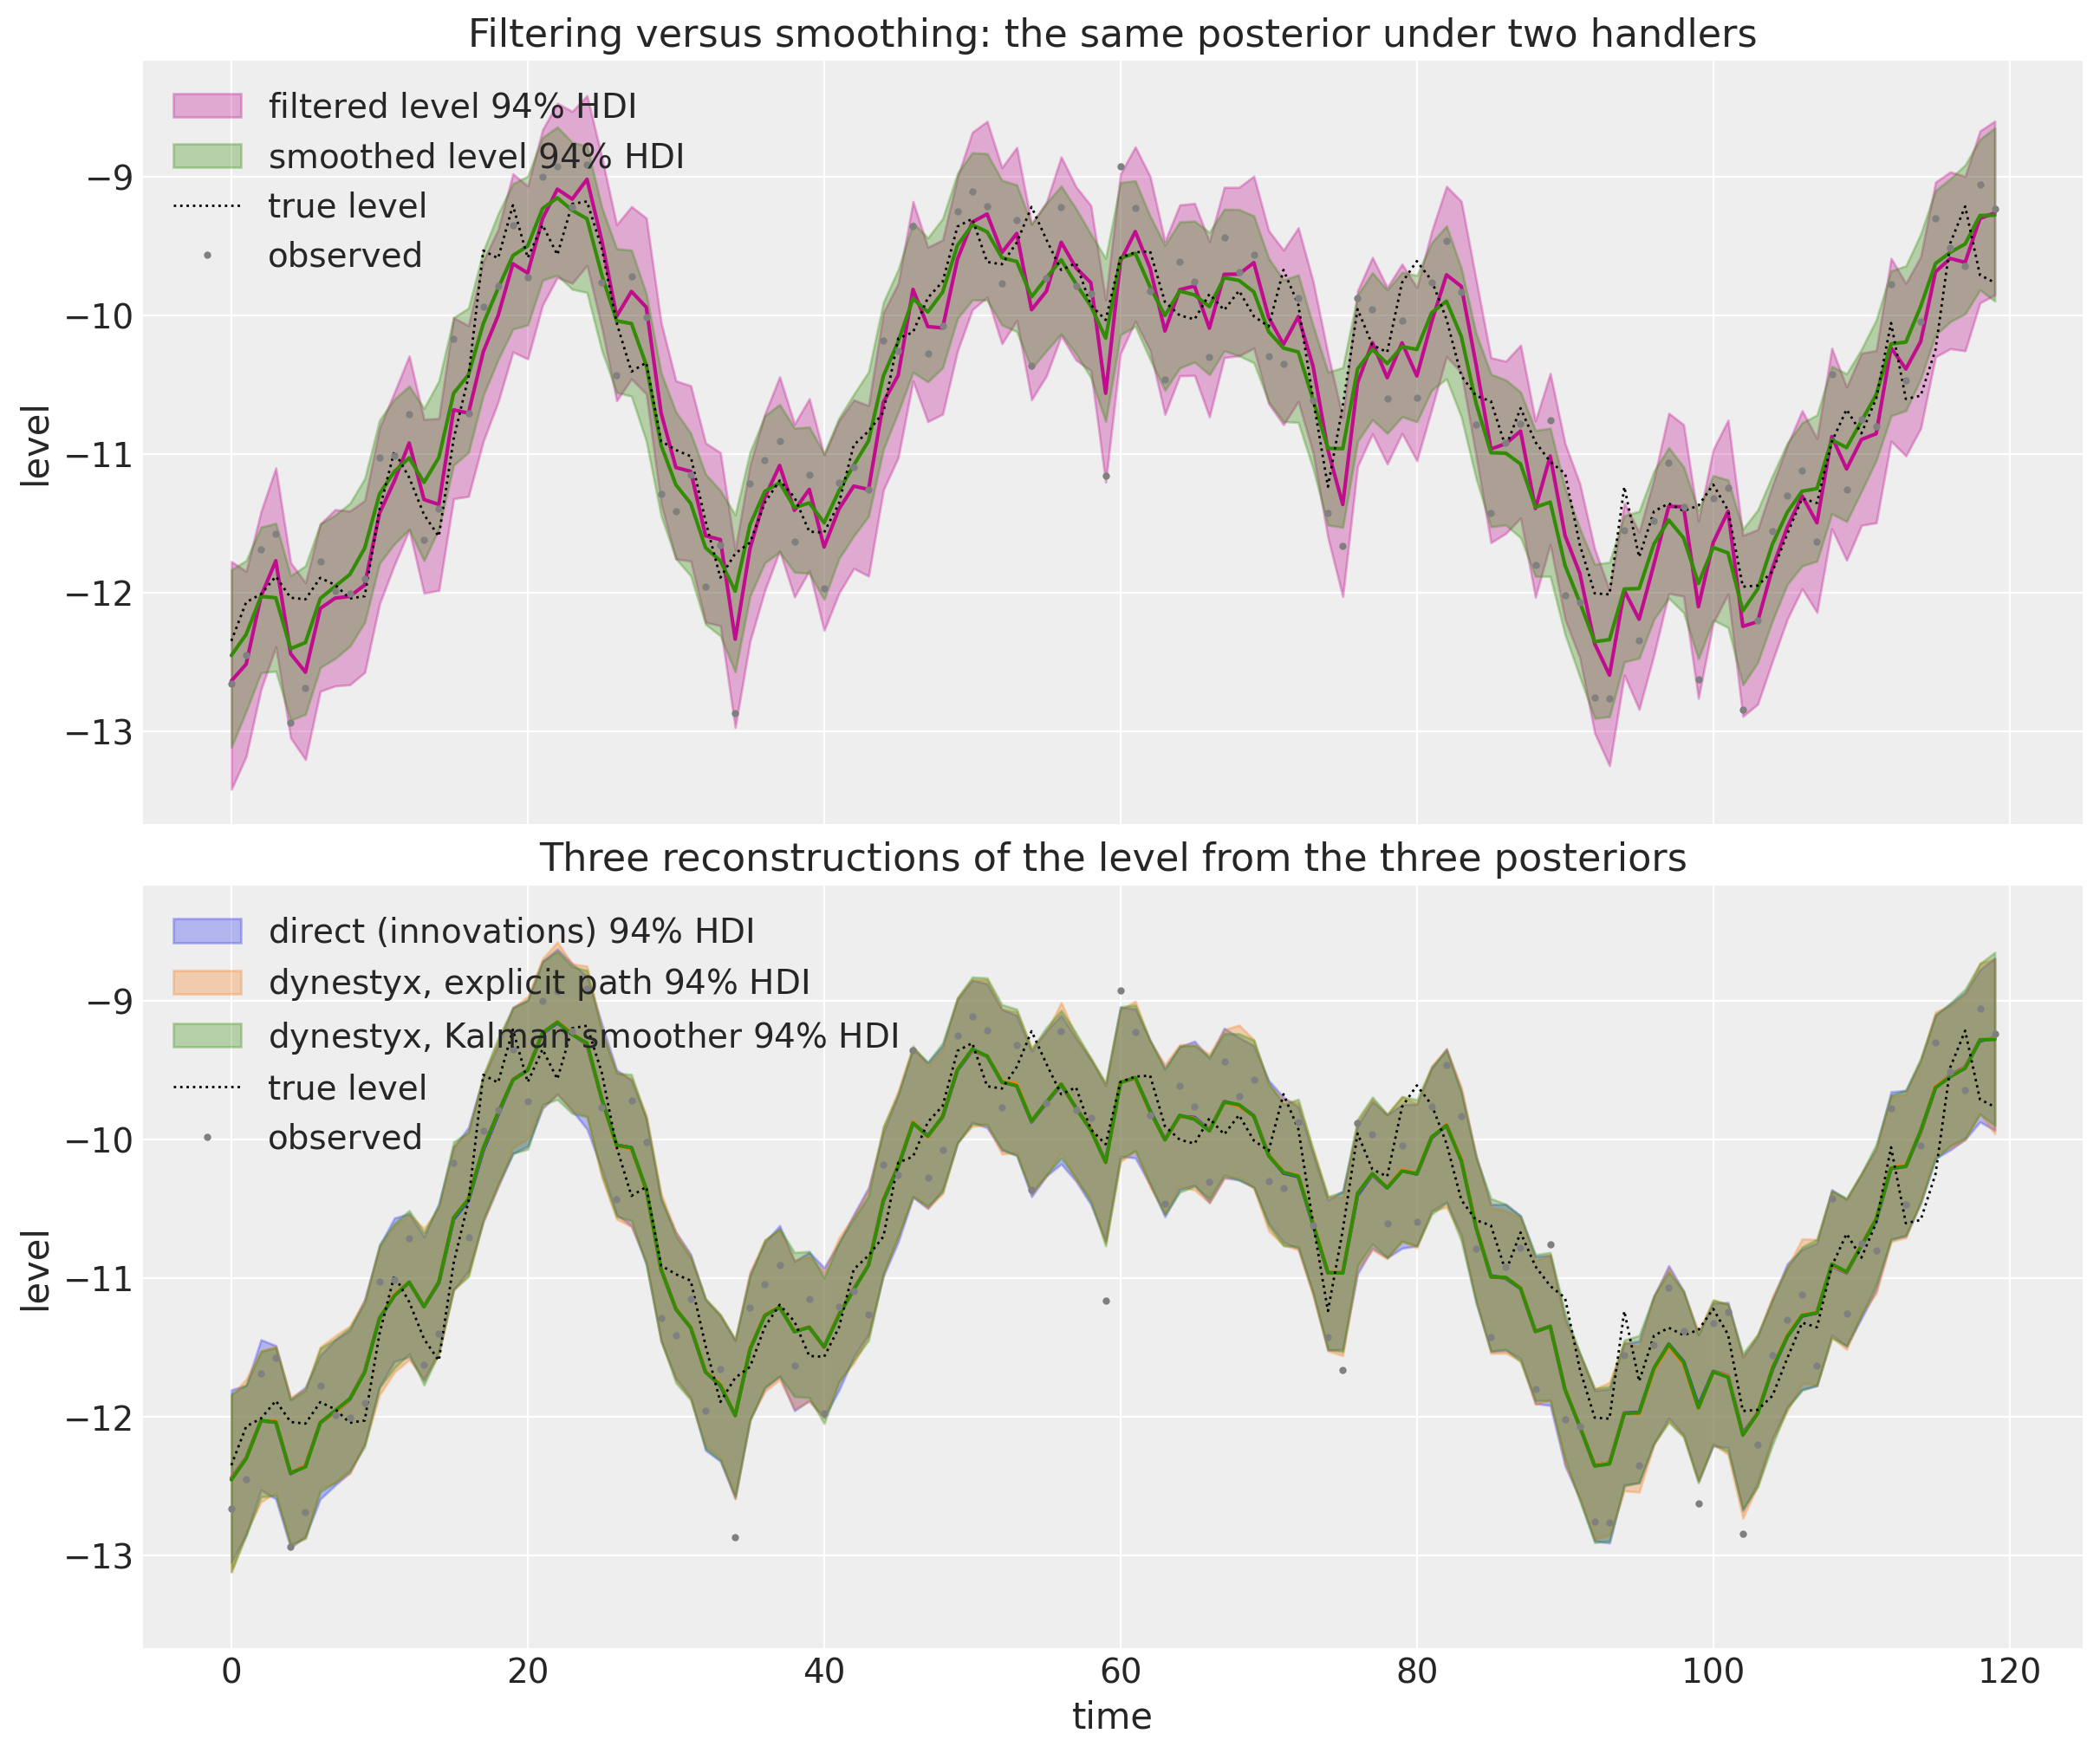

In [16]:
panels = {
    "Filtering versus smoothing: the same posterior under two handlers": {
        "filtered level": ("C3", filtered_level),
        "smoothed level": (
            colors["dynestyx, Kalman smoother"],
            levels["dynestyx, Kalman smoother"],
        ),
    },
    "Three reconstructions of the level from the three posteriors": {
        label: (colors[label], draws) for label, draws in levels.items()
    },
}
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 10), sharex=True, sharey=True, layout="constrained"
)
for ax, (title, bands) in zip(axes, panels.items(), strict=True):
    for label, (color, draws) in bands.items():
        lower, upper = hdi_over_draws(draws, 0.94)
        ax.fill_between(
            time_index[:t_obs],
            lower,
            upper,
            color=color,
            alpha=0.3,
            label=hdi_label(0.94, prefix=f"{label} "),
        )
        ax.plot(time_index[:t_obs], draws.mean(axis=0)[:, 0], color=color, lw=1.5)
    ax.plot(time_index[:t_obs], x_true[:t_obs], color="black", lw=1, ls=":", label="true level")
    ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="gray", ms=4, label="observed")
    ax.legend(loc="upper left")
    ax.set(title=title, ylabel="level")
axes[-1].set(xlabel="time");

In the top panel the filtered band is wider at the start of the window and lags the level, while the smoothed band uses the whole window. In the bottom panel the three reconstructions coincide: the direct model, the explicit path built by `dynestyx` and the smoother recover the same level from the same posterior, and the two `dynestyx` models did so through the same `x_in_sample` field.

## Seasonal Regression Model

The package routes everything a model needs at prediction time through the `covariates` array, which spans the full horizon. In this example the array carries two things. The observed series sits in its first column, which the model reads back as the observed window, and Fourier features fill the remaining columns, which the block forwards to `dynestyx` as control inputs (`ctrl_values`) on a time grid that covers both the observed and the predicted steps.

The seasonal pattern enters the observation equation as a regression on those features with coefficients $\beta$, so with $u_t$ the row of features at step $t$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + \beta^\top u_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` terms $\beta^\top u_t$ is the `D` matrix of `LTI_discrete`, which infers the control dimension from it since [dynestyx#361](https://github.com/BasisResearch/dynestyx/pull/361) (`dynestyx` $0.5.1$).

### Generate Data

We simulate the series with the same scales, the true coefficients `beta_true` and a period of $12$ steps with $2$ harmonics, again with `dsx.simulate`.

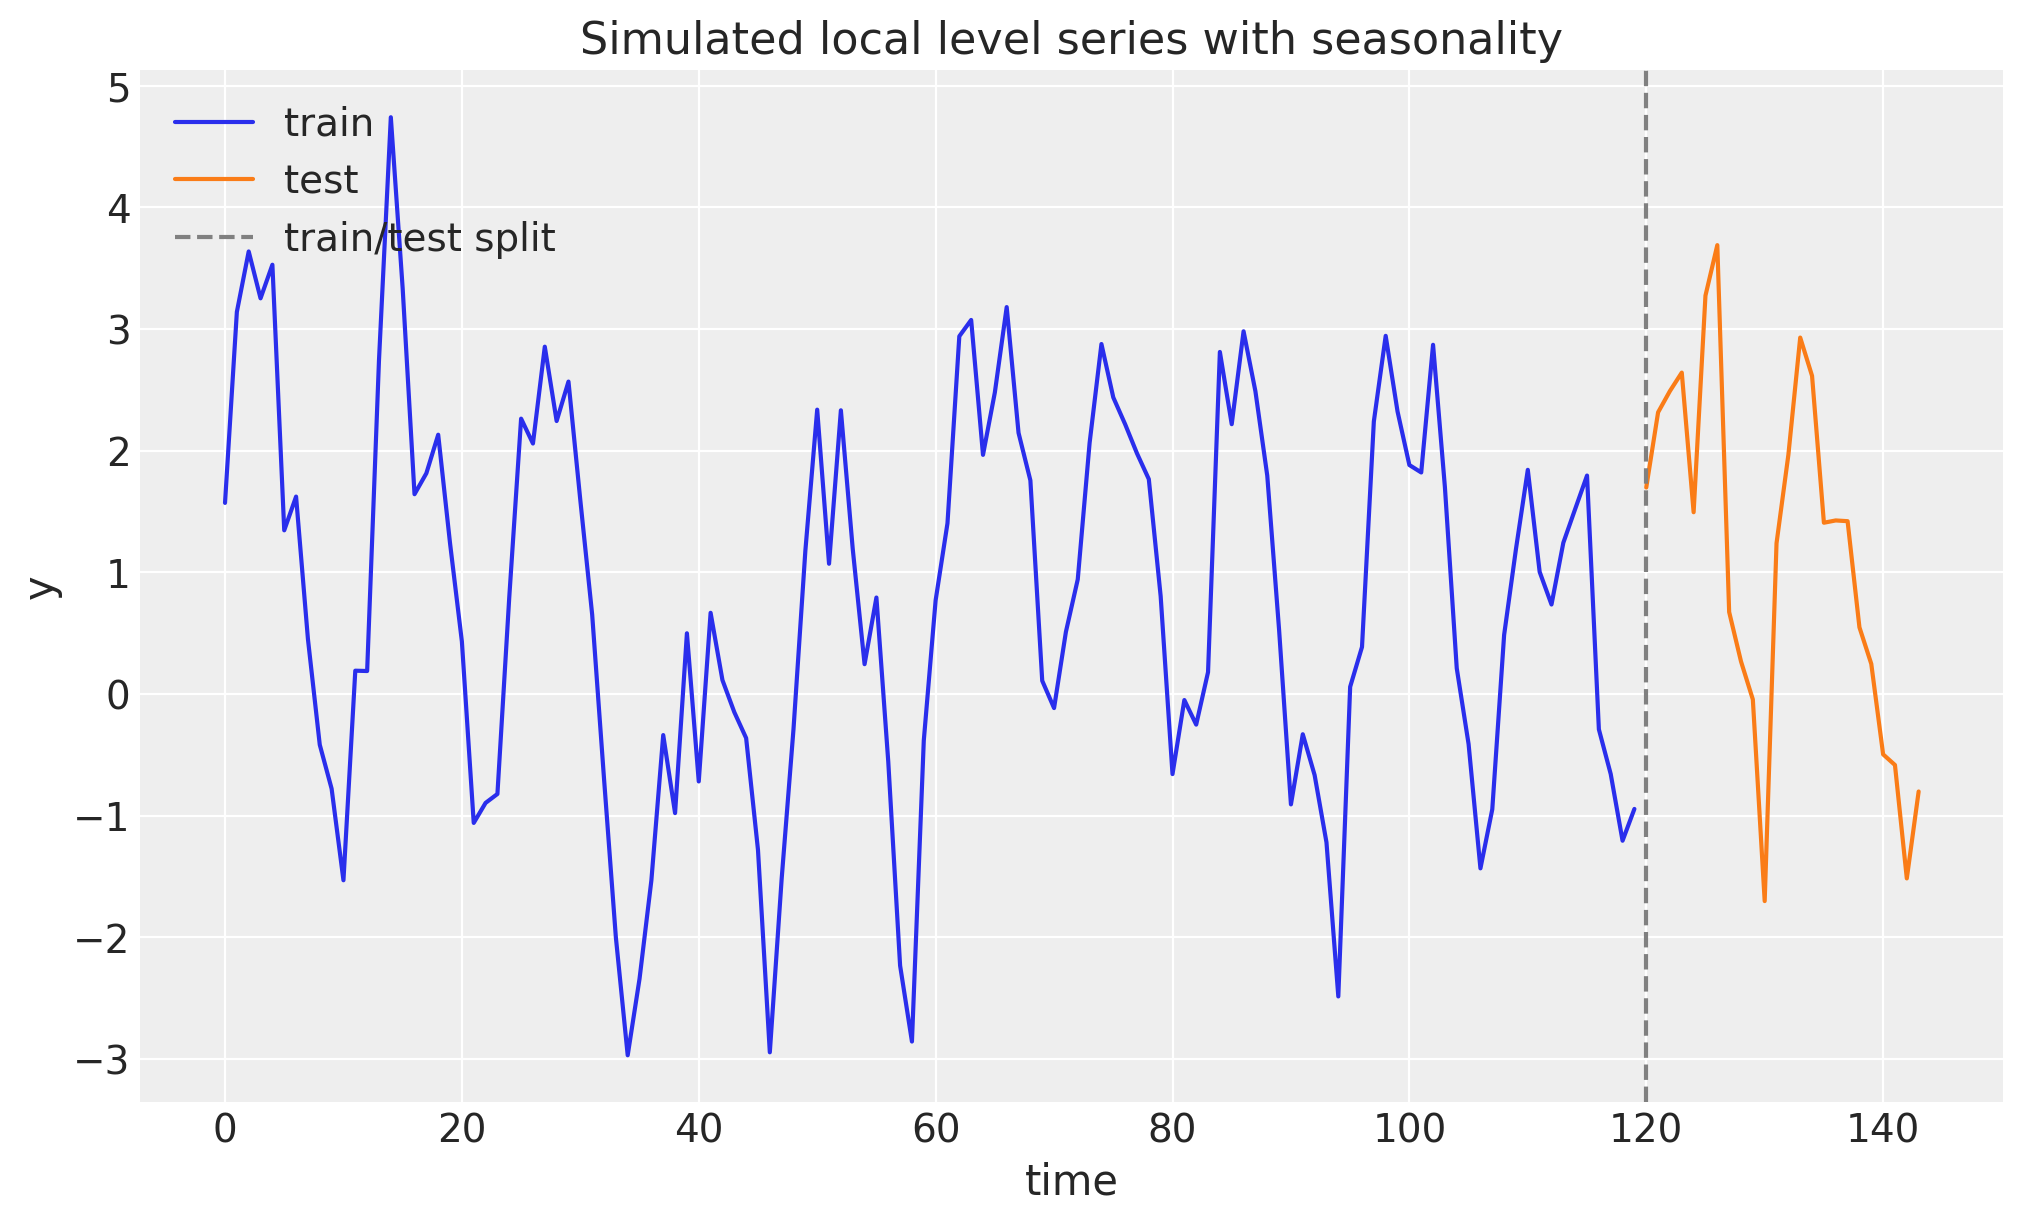

In [17]:
period, num_terms = 12.0, 2
beta_true = jnp.array([1.5, 0.5, -0.4, 0.3])
features_full = fourier_features(duration, period=period, num_terms=num_terms)  # (duration, 4)


def seasonal_level_dynamics(q: Array, r: Array, beta: Array) -> DynamicalModel:
    """Local level dynamics with a regression on the controls in the observation equation."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        D=beta[None, :],
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )


rng_key, rng_subkey = random.split(rng_key)
simulated_seasonal = dsx.simulate(
    seasonal_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true), beta_true),
    rng_key=rng_subkey,
    ctrl_times=jnp.asarray(time_grid),
    ctrl_values=features_full,
    predict_times=jnp.asarray(time_grid),
)
assert simulated_seasonal.observations is not None  # raw simulation
y_seasonal = simulated_seasonal.observations[0]  # (duration, 1)
train_seasonal, test_seasonal = y_seasonal[:t_obs], y_seasonal[t_obs:]
covariates_seasonal = jnp.concatenate([y_seasonal, features_full], axis=-1)  # (duration, 5)
covariates_seasonal_train = covariates_seasonal[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_seasonal[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_seasonal[:, 0], color="C1", label="test")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series with seasonality", xlabel="time", ylabel="y");

The seasonal pattern is visible on top of the wandering level.

### Model Specification

The model splits the covariate array into the observed window and the controls, adds a $\text{Normal}(0, 1)$ prior on the four coefficients, and conditions with the same smoother as before.

In [18]:
def seasonal_level_state_space(conditioner: StateSpaceHandler) -> ForecastModel:
    """Build the local level plus seasonal regression model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :1]  # the observed series is the first column
        controls = covariates[..., 1:]  # the Fourier features span the full horizon
        q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
        r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
        beta = jnp.asarray(
            numpyro.sample("beta", dist.Normal(0.0, 1.0).expand([controls.shape[-1]]).to_event(1))
        )
        state_space_series(
            h,
            "f",
            y,
            seasonal_level_dynamics(q, r, beta),
            conditioner=conditioner,
            controls=controls,
        )

    return model


seasonal_level_smoothed = seasonal_level_state_space(
    Smoother(smoother_config=KFSmootherConfig(filter_source="cd_dynamax"))
)

### Model Fitting

Variational inference is the other standard path in the package, and it works on the smoothed model unchanged. `AutoNormal` puts a mean-field Gaussian on the six unconstrained parameters and `Trace_ELBO` includes the smoother's factor.

Because the level is integrated out, the guide never has to approximate a $t_{\text{obs}}$-dimensional latent path, which is where mean-field guides usually underestimate uncertainty. We draw the posterior with [`draw_posterior`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.draw_posterior.html) and forecast as before.

SVI: 2.7 s, final loss 147.32
posterior mean of beta: [ 1.68  0.54 -0.38  0.23]
truth:                  [ 1.5  0.5 -0.4  0.3]


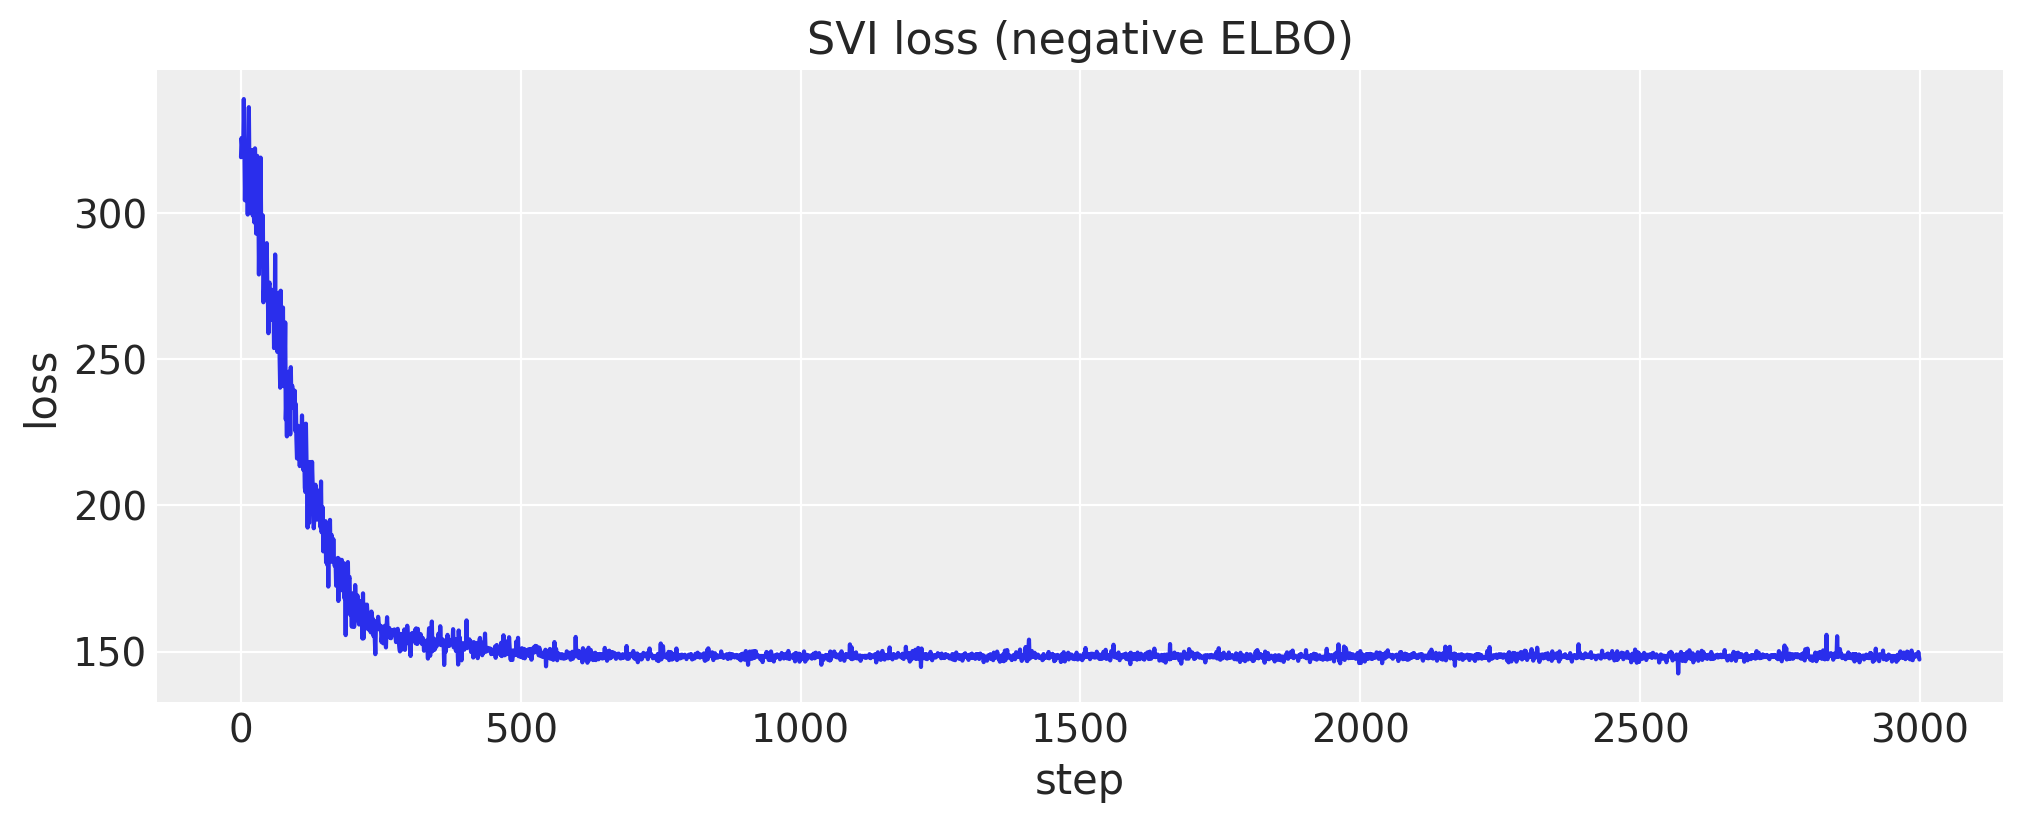

In [19]:
guide = AutoNormal(seasonal_level_smoothed)
svi = SVI(seasonal_level_smoothed, guide, Adam(step_size=0.01), Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
svi_result = svi.run(
    rng_subkey, 3_000, covariates_seasonal_train, train_seasonal, progress_bar=False
)
wall_svi = time.perf_counter() - start

rng_key, key_post, key_pred = random.split(rng_key, 3)
posterior_svi = draw_posterior(key_post, guide, svi_result.params, num_samples=2_000)
forecast_svi = forecast(
    key_pred, seasonal_level_smoothed, posterior_svi, train_seasonal, covariates_seasonal
)
print(f"SVI: {wall_svi:.1f} s, final loss {float(svi_result.losses[-1]):.2f}")
print(f"posterior mean of beta: {np.asarray(posterior_svi['beta']).mean(axis=0).round(2)}")
print(f"truth:                  {np.asarray(beta_true)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.asarray(svi_result.losses), color="C0")
ax.set(title="SVI loss (negative ELBO)", xlabel="step", ylabel="loss");

The loss flattens well before the $3{,}000$ steps, and the posterior mean of `beta` is close to the truth, which is good!

### Forecast

Let's plot the SVI forecast with `az.plot_lm`.

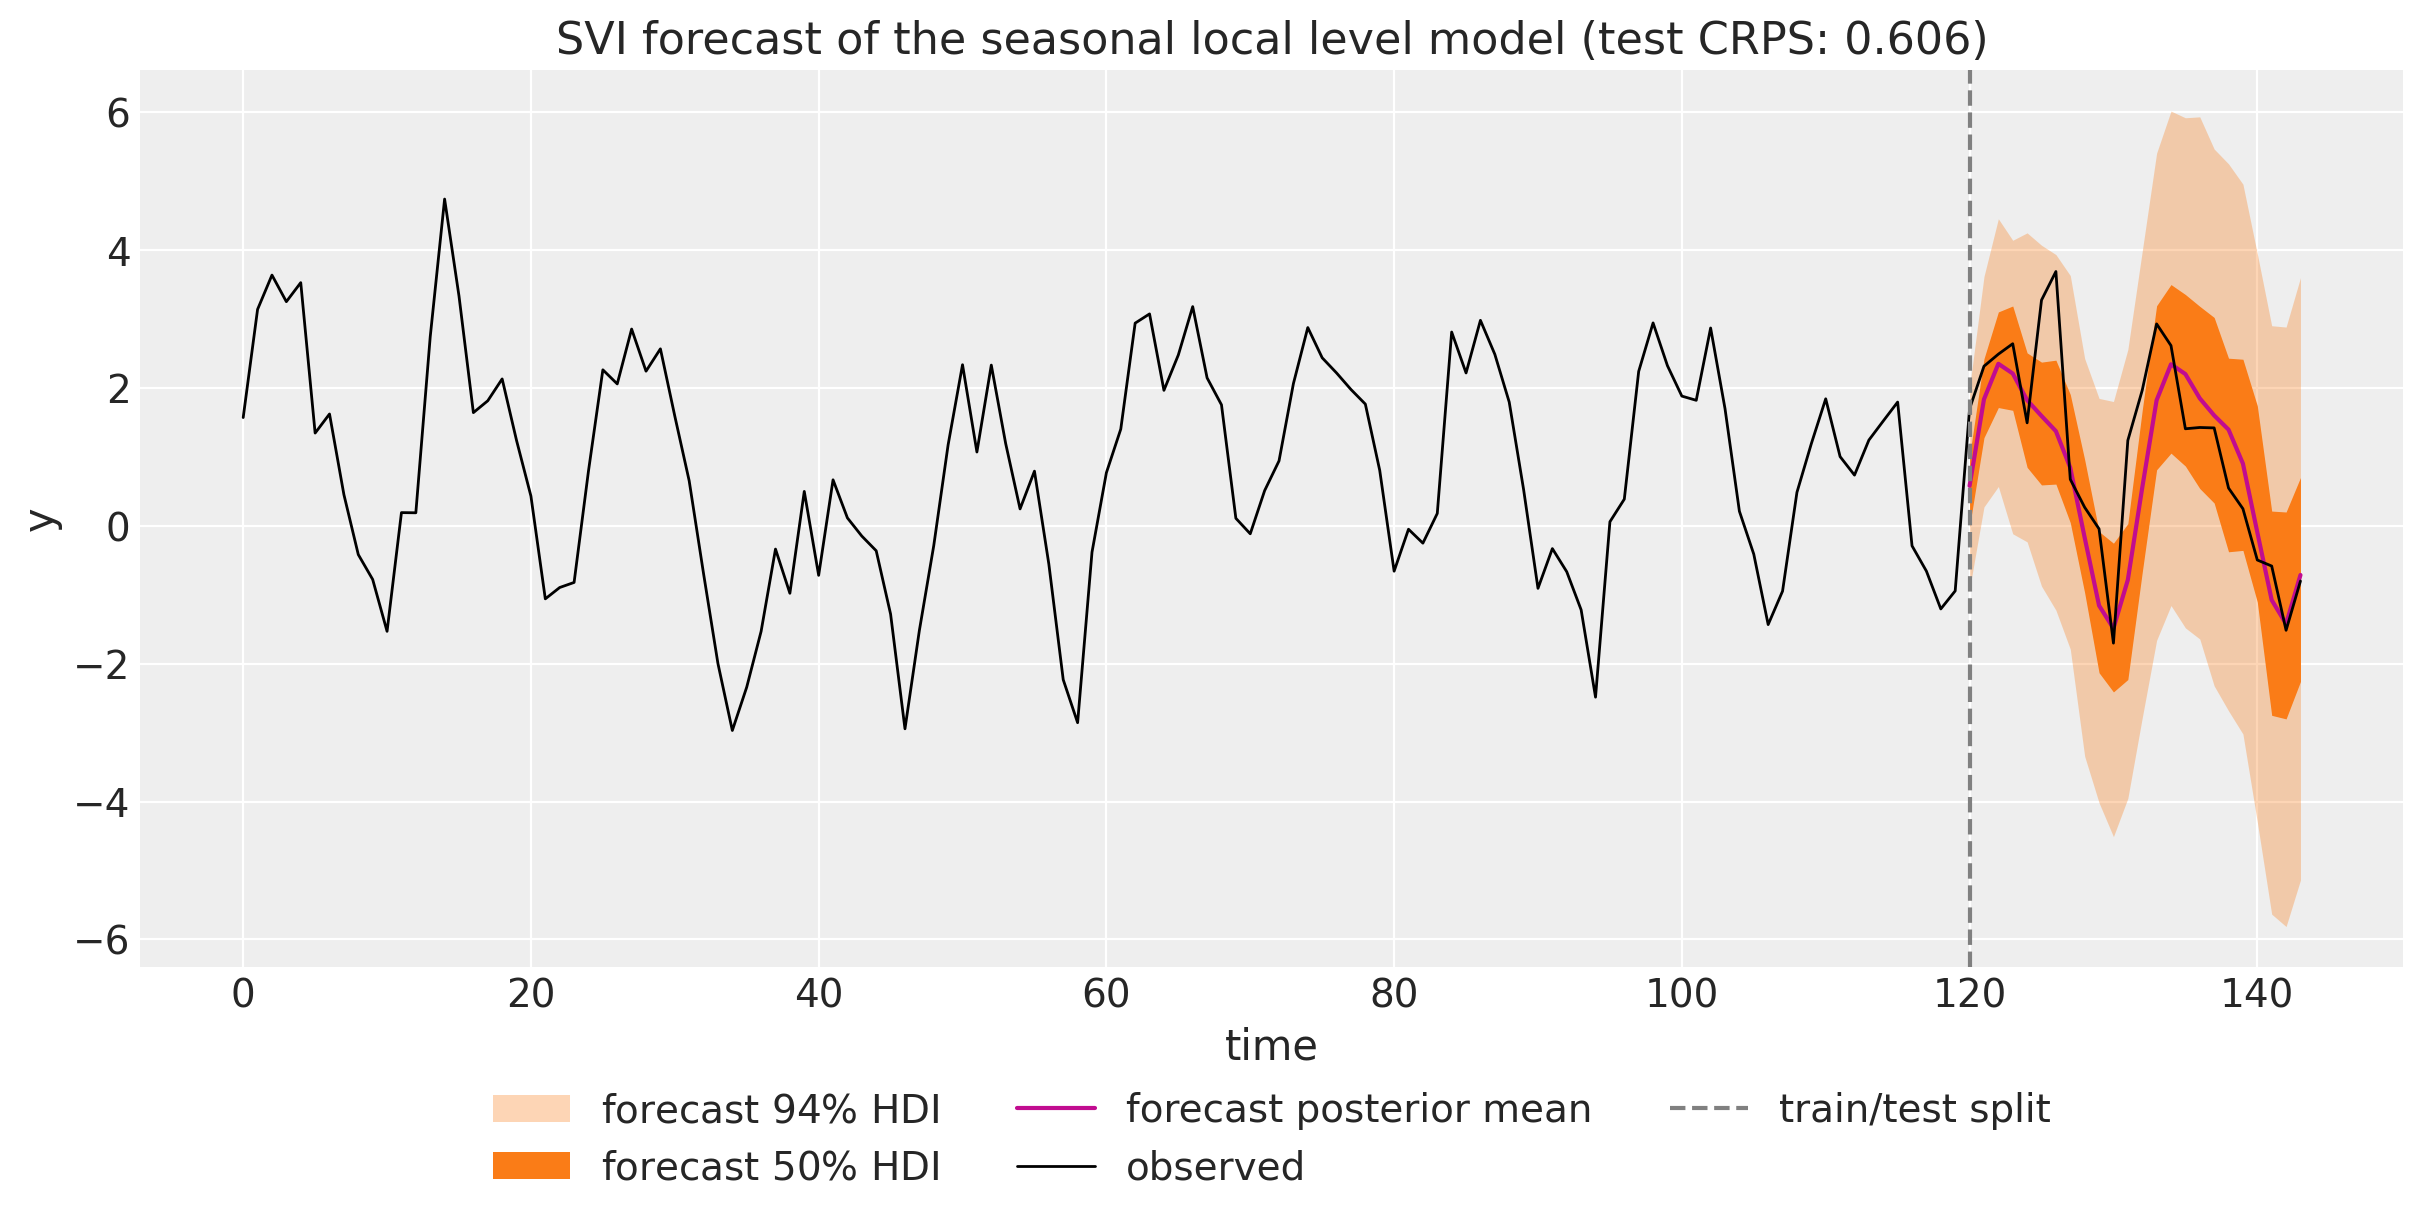

In [20]:
idata_forecast = predictions_to_datatree(
    forecast_svi, future_index.astype(float), ["y"], observed=test_seasonal
)
pc = az.plot_lm(
    idata_forecast,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
    },
    figure_kwargs={"figsize": (12, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("forecast posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_line = ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
crps_svi = eval_crps(forecast_svi, test_seasonal)
ax.set(
    title=f"SVI forecast of the seasonal local level model (test CRPS: {crps_svi:.3f})",
    xlabel="time",
    ylabel="y",
);

The forecast follows the seasonal pattern into the test window, and the bands widen slowly with the horizon.

### Expanding-Window Backtest

A single split scores one held-out window. [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) moves the train/test boundary forward, refits from scratch and forecasts the next window, so every later part of the series is scored out of sample once.

The loop delegates fitting and forecasting to two closures we write. `forecast_fn` fits the model with NUTS on the fold's training window and hands the draws to `forecast`, and `in_sample_fn` does the same and hands them to `predict_in_sample`, so that with `eval_train=True` every fold is also scored in sample.

The `dynestyx` model needs no adapter for any of this. It is a `numpyro_forecast` model, and the closures are the same ones the other examples use. We size the folds at $12$ steps (`test_window=12`, `stride=12`) with the first $72$ observations seeding the initial training window, which gives six folds.

In [21]:
def fit_fold(
    rng_key: Array, model: ForecastModel, train_data: Array, train_covariates: Array
) -> dict:
    """NUTS on one fold: 2 chains of 500 warmup and 500 draws, flattened."""
    mcmc, _ = fit_nuts(
        rng_key, model, train_data, train_covariates, num_chains=2, num_warmup=500, num_samples=500
    )
    return mcmc.get_samples()


def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


def in_sample_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and score its in-sample fit."""
    key_fit, key_pred = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return predict_in_sample(
        key_pred, model, fold_posterior, train_covariates, batch_size=batch_size
    )


backtest_metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
results = backtest(
    rng_subkey,
    y_seasonal,
    covariates_seasonal,
    lambda: seasonal_level_smoothed,
    forecast_fn=forecast_fn,
    in_sample_fn=in_sample_fn,
    metrics=backtest_metrics,
    test_window=12,
    stride=12,
    min_train_window=72,
    num_samples=1_000,  # 2 chains x 500 draws, what fit_fold returns
    eval_train=True,
    keep_predictions=True,
)
print(f"backtest: {len(results)} folds in {time.perf_counter() - start:.1f} s")
results_to_dataframe(results).round(3)

backtest: 6 folds in 82.7 s


,t0,t1,t2,num_samples,walltime,metric_crps,metric_coverage_50,metric_coverage_94,train_metric_crps,train_metric_coverage_50,train_metric_coverage_94
0,0,72,84,1000,6.226,0.682,0.250,1.000,0.218,0.708,1.0
1,0,84,96,1000,6.598,0.926,0.417,0.917,0.208,0.714,1.0
2,0,96,108,1000,7.382,0.407,0.917,1.000,0.215,0.729,1.0
3,0,108,120,1000,7.414,0.439,0.667,1.000,0.211,0.759,1.0
4,0,120,132,1000,7.627,0.658,0.667,1.000,0.203,0.775,1.0
5,0,132,144,1000,8.005,0.771,0.250,1.000,0.242,0.720,1.0


Every fold reports its window, its out-of-sample scores and, with `eval_train=True`, its in-sample scores. Overlaying every fold's out-of-sample forecast on the series gives the rolling-origin view. Each band starts where its training window ends, with the dashed lines marking the successive splits.

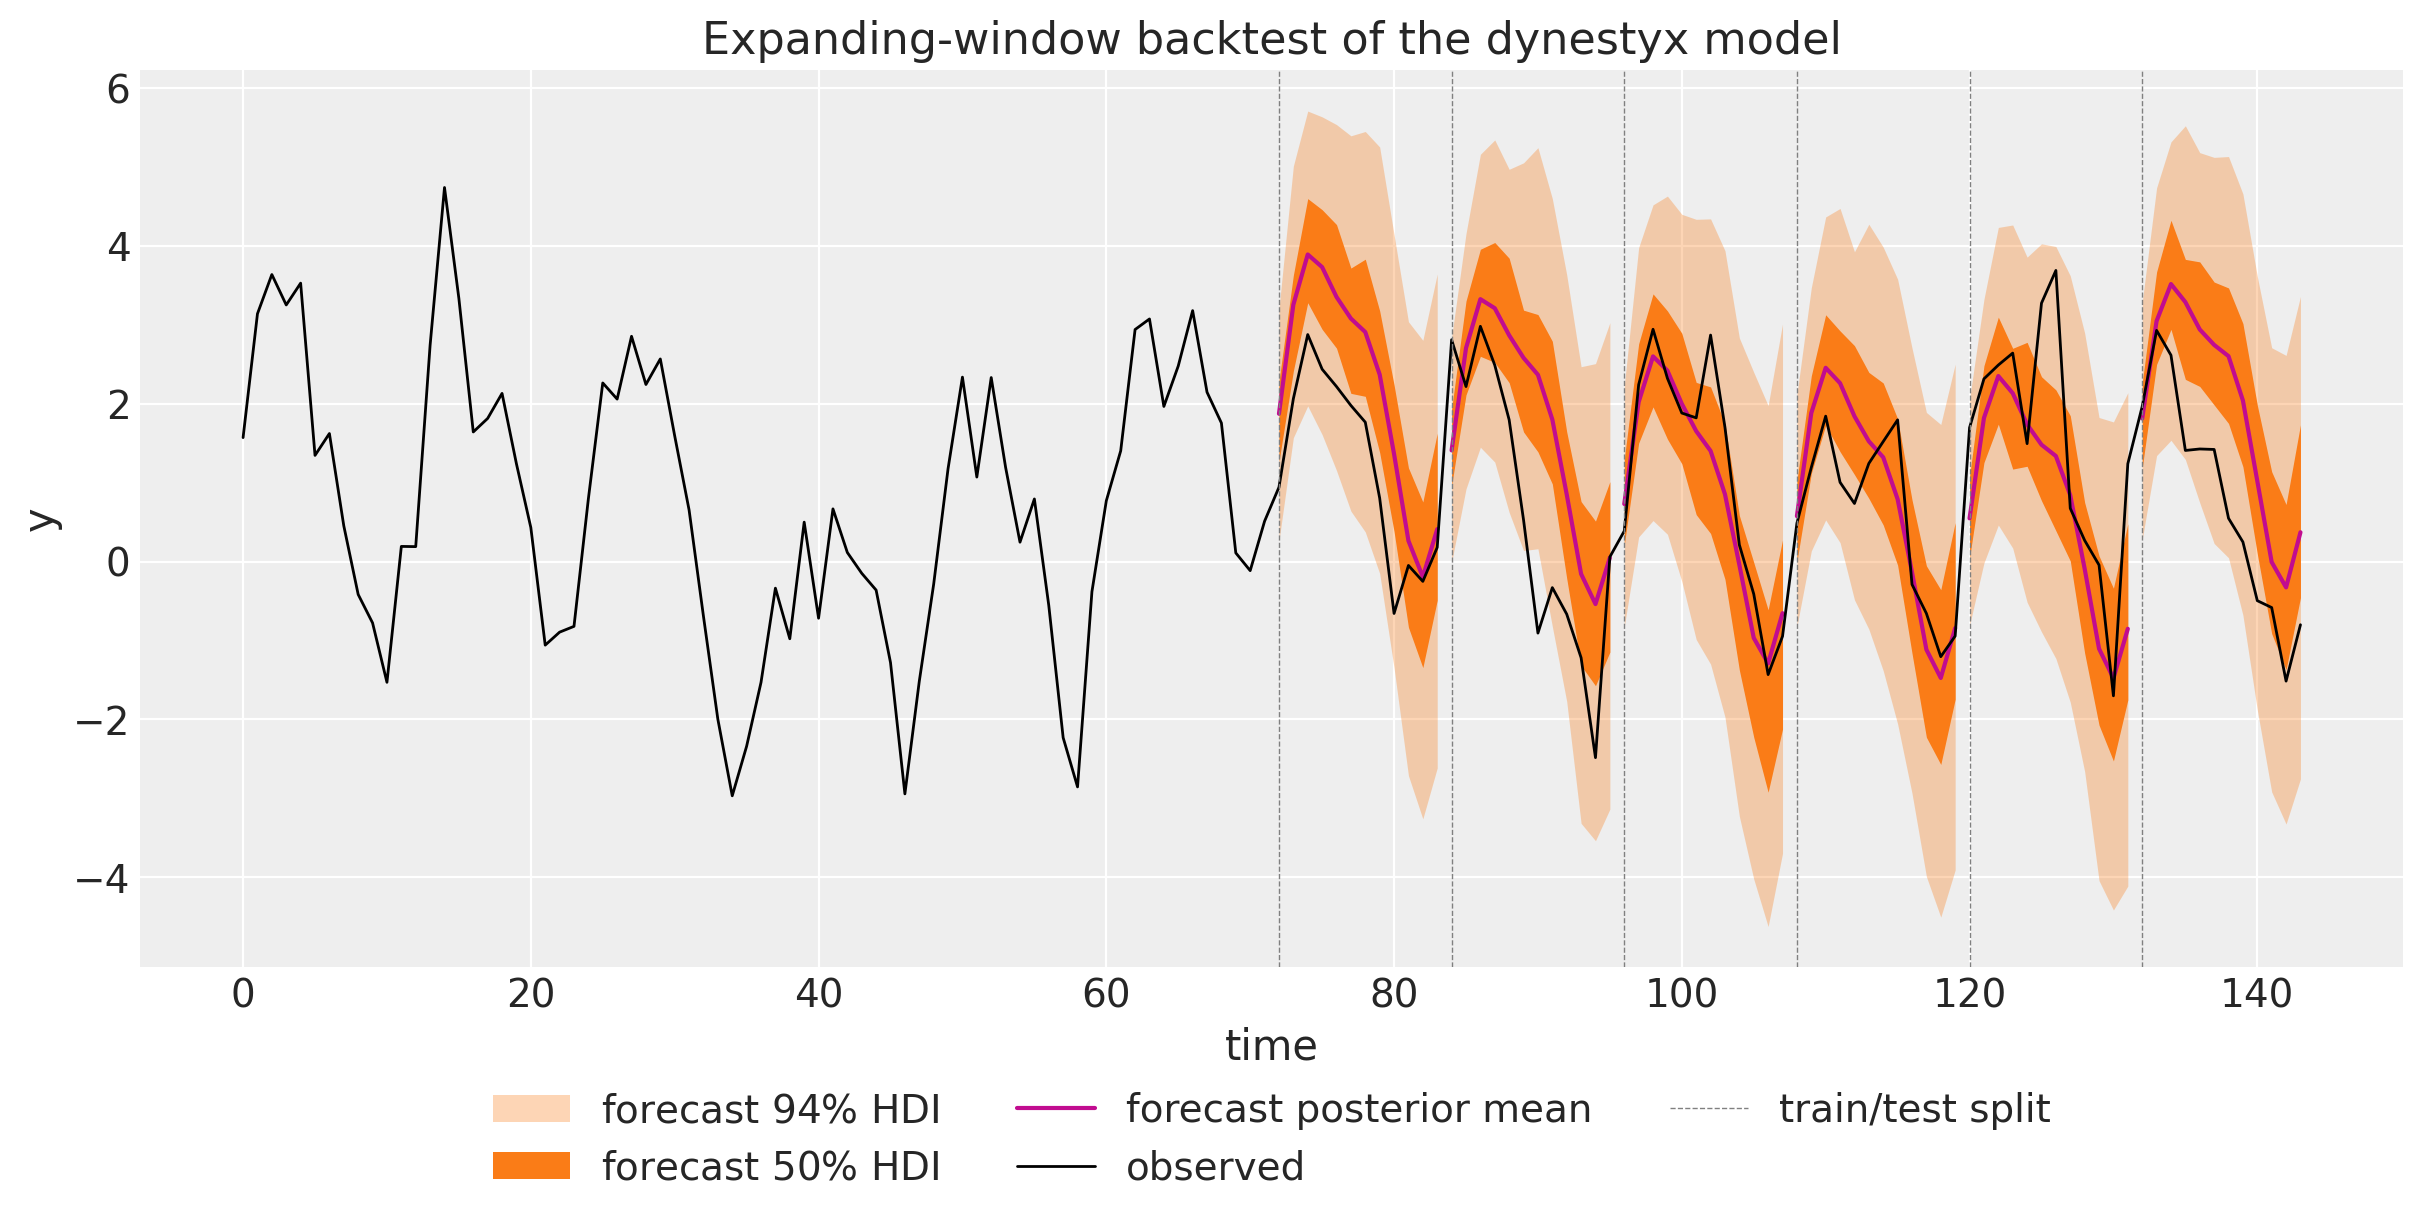

In [22]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time_index[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(
        prediction, fold_time, ["y"], observed=y_seasonal[r.t1 : r.t2]
    )
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window backtest of the dynestyx model", xlabel="time", ylabel="y");

The bands track the series across all six folds. Finally, let's look at the per-fold scores.

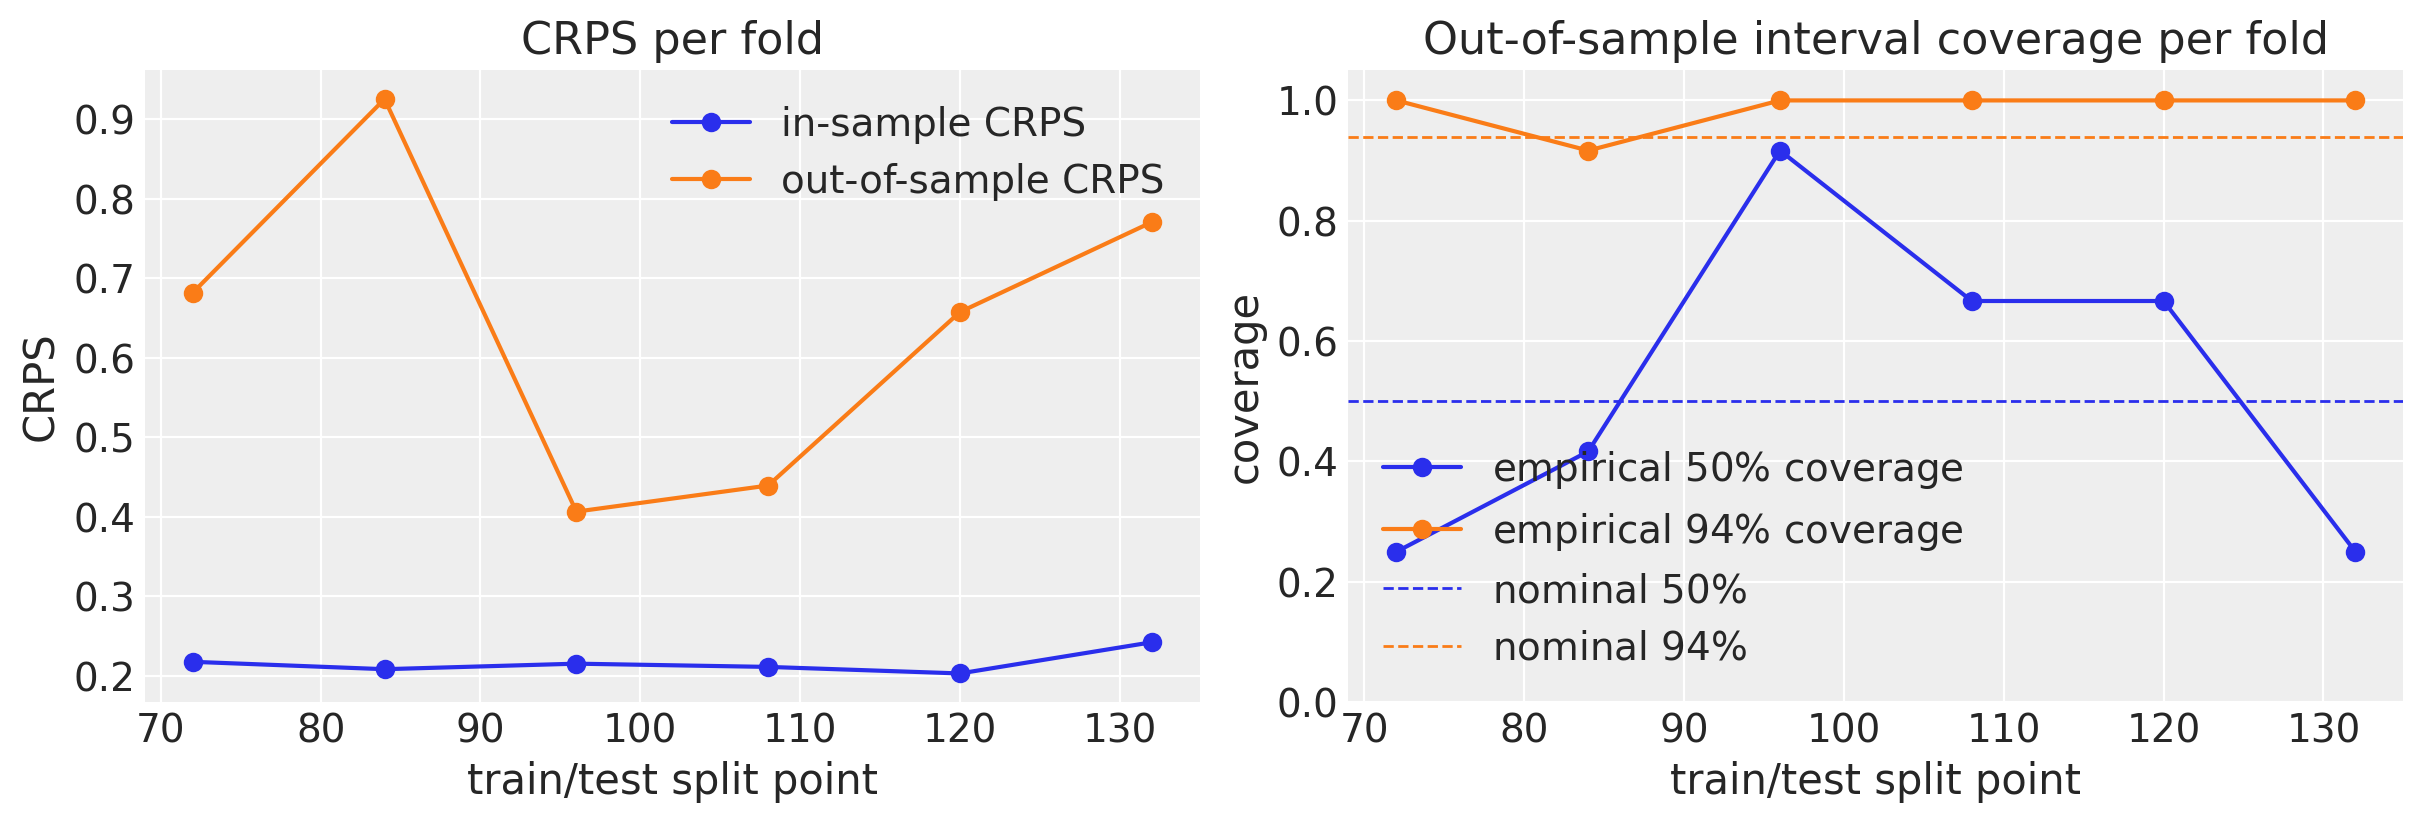

In [23]:
split_points = [r.t1 for r in results]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
axes[0].plot(
    split_points,
    [r.train_metrics["crps"] for r in results],
    "o-",
    color="C0",
    label="in-sample CRPS",
)
axes[0].plot(
    split_points,
    [r.metrics["crps"] for r in results],
    "o-",
    color="C1",
    label="out-of-sample CRPS",
)
axes[0].legend()
axes[0].set(xlabel="train/test split point", ylabel="CRPS", title="CRPS per fold")
axes[1].plot(
    split_points,
    [r.metrics["coverage_50"] for r in results],
    "o-",
    color="C0",
    label=r"empirical $50\%$ coverage",
)
axes[1].plot(
    split_points,
    [r.metrics["coverage_94"] for r in results],
    "o-",
    color="C1",
    label=r"empirical $94\%$ coverage",
)
axes[1].axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
axes[1].axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
axes[1].legend(loc="lower left")
axes[1].set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

The in-sample CRPS is flat across folds, between $0.20$ and $0.23$, and well below the out-of-sample CRPS, as it must be for a smoothing predictive that has seen the observations it scores.

Out of sample, the third fold (split at $96$) is the outlier. The series drops further in that window than the forecast expects, so its CRPS reaches $0.51$ and its $94\%$ coverage falls to $0.83$. The other five folds stay between $0.31$ and $0.41$.

The empirical coverage of the central $50\%$ interval wobbles between $0.33$ and $0.67$ around the nominal level, and the $94\%$ interval covers at least $11$ of the $12$ observations in every other fold. This is expected with $12$ observations per fold, since each observation moves the coverage by about $0.08$.

## Conclusion

### Key Findings

- **One block, one argument.** A `dynestyx` model becomes a `numpyro_forecast` model through `state_space_series`, and the handler stack passed as its `conditioner` is the inference strategy. A `Smoother` (or `Filter`) marginalizes the latent path, a `LatentPathBuilder` samples it explicitly, a `Discretizer` after either handles continuous-time dynamics, and switching between them is a one-argument change.
- **The drivers work unchanged.** The block owns the likelihood and registers the horizon rollout as `"forecast"` and the in-sample predictive as `"obs"`, so `forecast`, `predict_in_sample`, `to_datatree`, `backtest` (in and out of sample) and the metrics work on it under the same `jit` and `vmap` as for every other model.
- **The three strategies agree.** On the local level model the posteriors, the forecasts, the in-sample bands and the reconstructed level coincide across the direct model, the explicit path and the smoother.
- **The smoother is the efficient choice.** On linear-Gaussian models it is exact and costs the same per gradient as the filter. The sampler explores the parameters only, needs a small fraction of the gradient evaluations of the direct model for a larger effective sample size, and the smoothing distribution gives the in-sample predictive for free.

### Model Limitations

- `dynestyx` predicts at or after the end of the window only, so the in-sample predictive comes from the conditioned distributions rather than from a rollout, and it is a per-step marginal. A functional of the whole path would need backward simulation.
- A `Filter` conditioner has no in-sample predictive. Use a `Smoother`, which costs the same during fitting.
- The observed window travels in the covariates, so the time grids are host-side constants for the smoother's rollout and jax arrays for the builder, and the rollout is anchored at the last observed step. The block owns both traps, and a rewrite that derives `times` from a covariate column would break the first.
- The `ssoe` family of the package with a latent level (exponential smoothing in innovations form) is already marginalized by its deterministic recursion and has no `dynestyx` counterpart. Its members that are Markov in the observations (autoregressions) can be written with `DiracIdentityObservation` under a `LatentPathBuilder`, see the design document.

### Recommendations

1. Reach for a `Smoother` with `KFSmootherConfig(filter_source="cd_dynamax")` on linear-Gaussian models, and switch to `filter_source="cuthbert"` when you need missing observations, time-varying parameters or a GPU on long series.
2. Use a `LatentPathBuilder` when the path itself is the object of interest, the observation model is non-Gaussian, or the dynamics are discretized continuous-time.
3. Put `LocScaleReparam` on the direct model in any comparison, as we did here.
4. Create the `dynestyx` handlers once, outside the model, and pass the KF configurations explicitly, since the `dynestyx` defaults are approximate filters.

## Next Steps

1. **Continuous-time dynamics.** A mean-reverting level on irregularly spaced observations, with a `Discretizer` after the smoother, is the case `dynestyx` supports and the index-based blocks of the package cannot express. The design document records the recipe and the caveats that keep it out of this notebook for now.
2. **Nonlinear and non-Gaussian models.** The approximate filters and smoothers of `dynestyx` (ensemble, extended, unscented and particle) give pseudo-marginal inference beyond the linear-Gaussian case, with the same block.
3. **Missing observations.** The `cuthbert` backend and the builder's `missing_observation_strategy` handle `NaN` values in the window, which the models of the package do not.
4. **A `contrib` module.** Once the maintainers of both libraries have reviewed the composition, the block moves to `numpyro_forecast.contrib.dynestyx` and this notebook imports it.

## References

- Waxman, D., Batenkov, D., Feser, J., Zane, A., Bingham, E., Marzouk, Y., & Levine, M. E. (2026). [*Dynestyx: A Probabilistic Programming Library for Dynamical Systems*](https://arxiv.org/abs/2606.16985).
- [`dynestyx` documentation](https://basisresearch.github.io/dynestyx/stable/), in particular the tutorials on [filtering and the marginal likelihood](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/03_filtering_mll/) and on [discrete-time smoothing](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/09_discrete_smoothing/).
- Durbin, J., & Koopman, S. J. (2012). *Time Series Analysis by State Space Methods*, 2nd edition. Oxford University Press.
- Särkkä, S., & Svensson, L. (2023). [*Bayesian Filtering and Smoothing*](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf), 2nd edition. Cambridge University Press.
- [`DYNESTYX_INTEGRATION_DESIGN.md`](https://github.com/juanitorduz/numpyro_forecast/blob/main/DYNESTYX_INTEGRATION_DESIGN.md), the design document behind this notebook.